# Separated vs Shared Encoding notebook scaffold

Scaffold for comparing the full baseline model against feature-group-specific models (financial, creative, metadata). The logic is unchanged; this notebook focuses on clear structure, consistent globals, and organized artifacts for plots/results.

## Intro & goals
We compare the shared-encoder baseline against three feature-group-specific models while keeping the architecture fixed. The goal is to assess whether semantic separation helps or hurts predictive performance.

## Outline
- Intro & goals
- Imports & config
- Artifacts & output structure
- Baseline architecture reference
- Data prep & feature groups
- Loader helpers
- Model setup
- Training loop
- Predictions & evaluation
- Results aggregation
- Plotting
- Ensemble variants
- Fusion experiments
- Comprehensive comparison
- Test set evaluation
- Notes

## Imports & config
Set paths, device, and reproducibility settings before data prep. Artifacts are stored under the notebook's `artifacts/` directory.

In [ ]:
import os
import sys
import time
import json
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "seperated_vs_shared_encoding"

import data.encode_features as enc
from models.model import TabularRegressor
from models.encoders import SharedTabularEncoder
from models.heads import RegressionHead

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
def seed_everything(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(42)

Using device: cpu


## Artifacts & output structure
Organize outputs (predictions, histories, plots, summaries, checkpoints) under the notebook's artifacts folder for reproducibility.

In [3]:
# Create organized directory structure for outputs
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = ARTIFACT_ROOT
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
HISTORIES_DIR = RESULTS_DIR / "training_histories"
PLOTS_DIR = RESULTS_DIR / "plots"
SUMMARIES_DIR = RESULTS_DIR / "summaries"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"

# Create all directories
for dir_path in [PREDICTIONS_DIR, HISTORIES_DIR, PLOTS_DIR, SUMMARIES_DIR, CHECKPOINTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print(f"Results will be saved to: {RESULTS_DIR.absolute()}")
print(f"  - Predictions: {PREDICTIONS_DIR}")
print(f"  - Histories: {HISTORIES_DIR}")
print(f"  - Plots: {PLOTS_DIR}")
print(f"  - Summaries: {SUMMARIES_DIR}")
print(f"  - Checkpoints: {CHECKPOINTS_DIR}")

Results will be saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding
  - Predictions: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\predictions
  - Histories: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories
  - Plots: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots
  - Summaries: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\summaries
  - Checkpoints: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\checkpoints


## Baseline architecture reference
We inspect the shared-encoder baseline from `src/models/model.py` and reuse it unchanged for all feature-group models.

In [ ]:
# Load baseline artifacts (config, history, metrics, checkpoint)
BASELINE_ROOT = NOTEBOOK_DIR / "artifacts" / "baseline"
BASELINE_RESULTS = BASELINE_ROOT / "results"
BASELINE_CHECKPOINTS = BASELINE_ROOT / "checkpoints"

baseline_config_path = BASELINE_RESULTS / "config.json"
baseline_history_path = BASELINE_RESULTS / "training_history.csv"
baseline_metrics_path = BASELINE_RESULTS / "test_metrics.csv"
baseline_model_path = BASELINE_CHECKPOINTS / "tabular_regressor.pt"

with baseline_config_path.open("r") as f:
    baseline_cfg = json.load(f)

baseline_history_df = pd.read_csv(baseline_history_path)
baseline_metrics_df = pd.read_csv(baseline_metrics_path)

BASELINE_ENCODER_HIDDEN = tuple(baseline_cfg["encoder_hidden"])
BASELINE_HEAD_HIDDEN = tuple(baseline_cfg.get("head_hidden", []))
BASELINE_DROPOUT = float(baseline_cfg.get("dropout", 0.1))
BATCH_SIZE = int(baseline_cfg.get("batch_size", 256))

# Define baseline architecture specification (from baseline artifacts)
BASELINE_ARCHITECTURE = {
    "class": "TabularRegressor",
    "mode": "shared",
    "encoder": "SharedTabularEncoder",
    "encoder_hidden": BASELINE_ENCODER_HIDDEN,
    "head_hidden": BASELINE_HEAD_HIDDEN,
    "head_class": "RegressionHead",
    "dropout": BASELINE_DROPOUT,
    "description": f"SharedTabularEncoder: input -> {' -> '.join(str(h) for h in BASELINE_ENCODER_HIDDEN)} -> output. RegressionHead: encoder_out -> 1"
}

# Document architecture details
encoder_hidden_str = ", ".join(str(h) for h in BASELINE_ENCODER_HIDDEN)
encoder_path = " -> ".join(
    [f"Linear({h}) -> ReLU -> Dropout({BASELINE_DROPOUT})" for h in BASELINE_ENCODER_HIDDEN]
)
if BASELINE_HEAD_HIDDEN:
    head_hidden_str = ", ".join(str(h) for h in BASELINE_HEAD_HIDDEN)
    head_path = " -> ".join(
        [
            *(f"Linear({h}) -> ReLU -> Dropout({BASELINE_DROPOUT})" for h in BASELINE_HEAD_HIDDEN),
            "Linear(1)",
        ]
    )
else:
    head_hidden_str = "none"
    head_path = "Linear(1)"

print("=" * 80)
print("BASELINE ARCHITECTURE SPECIFICATION")
print("=" * 80)
for key, value in BASELINE_ARCHITECTURE.items():
    print(f"{key:20s}: {value}")
print("=" * 80)
print("\nArchitecture Details:")
print(f"- Encoder: SharedTabularEncoder with hidden layers ({encoder_hidden_str})")
print(f"- Encoder path: input_dim -> {encoder_path}")
print(f"- Head: RegressionHead (hidden layers: {head_hidden_str})")
print(f"- Head path: {head_path}")
print("- Output: Single scalar prediction (log-transformed gross)")
print("=" * 80)

BASELINE ARCHITECTURE SPECIFICATION
class               : TabularRegressor
mode                : shared
encoder             : SharedTabularEncoder
encoder_hidden      : (256, 128, 64)
head_hidden         : ()
head_class          : RegressionHead
dropout             : 0.1
description         : SharedTabularEncoder: input -> 256 -> 128 -> 64 -> output. RegressionHead: encoder_out -> 1

Architecture Details:
- Encoder: SharedTabularEncoder with hidden layers (256, 128, 64)
- Encoder path: input_dim -> Linear(256) -> ReLU -> Dropout(0.1) ->
                Linear(128) -> ReLU -> Dropout(0.1) ->
                Linear(64) -> ReLU -> Dropout(0.1)
- Head: RegressionHead (no hidden layers)
- Head path: 64 -> Linear(1)
- Output: Single scalar prediction (log-transformed gross)


## Data prep & feature groups
Load train/val/test splits and apply the same preprocessing pipeline as the baseline. Define semantic feature groups for focused modeling.

In [5]:
# Data configuration
ALL_FEATURES_DIR = "../data/processed/all_features"
TARGET_COL = "gross"

NUMERIC_COLS = ["budget", "year", "votes", "runtime", "score"]
CAT_COLS = ["company", "genre", "director", "writer", "star", "country", "rating"]

# Feature groups (Semantic Categorization)
FEATURE_GROUPS = {
    "baseline": {
        "name": "All Features (Baseline)",
        "numeric_indices": [0, 1, 2, 3, 4],  # budget, year, votes, runtime, score
        "categorical_indices": [0, 1, 2, 3, 4, 5, 6],  # company, genre, director, writer, star, country, rating
    },
    "financial": {
        "name": "Financial (Economic Context)",
        "numeric_indices": [0, 1, 2],  # budget, year, votes
        "categorical_indices": [0],  # company
    },
    "creative": {
        "name": "Creative (Core Talent)",
        "numeric_indices": [],
        "categorical_indices": [1, 2, 3, 4],  # genre, director, writer, star
    },
    "metadata": {
        "name": "Metadata (Cataloging Specs)",
        "numeric_indices": [3, 4],  # runtime, score
        "categorical_indices": [5, 6],  # country, rating
    },
}

# Load data
train_df = pd.read_csv(os.path.join(ALL_FEATURES_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(ALL_FEATURES_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(ALL_FEATURES_DIR, "test.csv"))

print(f"Train shape: {train_df.shape}")
print(f"Val shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nColumns: {list(train_df.columns)[:15]}...")  # Show first 15 columns

Train shape: (3804, 15)
Val shape: (815, 15)
Test shape: (816, 15)

Columns: ['name', 'rating', 'genre', 'year', 'released', 'score', 'votes', 'director', 'writer', 'star', 'country', 'budget', 'gross', 'company', 'runtime']...


In [6]:
# Preprocessing functions (replicate from notebook 04)
def build_cat_vocab(train_series: pd.Series, min_freq=5):
    """Build categorical vocabulary with rare grouping."""
    s = train_series.fillna("Unknown").astype(str)
    vc = s.value_counts()
    keep = set(vc[vc >= min_freq].index)
    s2 = s.where(s.isin(keep), "Other")
    
    vocab = {cat: i for i, cat in enumerate(sorted(s2.unique()))}
    if "Unknown" not in vocab:
        vocab["Unknown"] = len(vocab)
    if "Other" not in vocab:
        vocab["Other"] = len(vocab)
    
    return vocab, keep

def apply_cat_vocab(series: pd.Series, vocab: dict, keep: set):
    """Apply vocabulary to a categorical column."""
    s = series.fillna("Unknown").astype(str)
    s = s.where(s.isin(keep), "Other")
    return s.map(lambda x: vocab.get(x, vocab["Unknown"])).astype(np.int64).values

def fit_numeric_stats(df: pd.DataFrame, numeric_cols):
    """Fit numeric preprocessing statistics on training data."""
    df = df.copy()
    
    # Log transform budget, votes
    if "budget" in df.columns:
        df["budget"] = np.log1p(df["budget"].astype(float))
    if "votes" in df.columns:
        df["votes"] = np.log1p(df["votes"].astype(float))
    
    # Standardization (no imputation needed - data is clean)
    mean = df[numeric_cols].mean()
    std = df[numeric_cols].std().replace(0, 1.0)
    
    return mean, std

def transform_numeric(df: pd.DataFrame, numeric_cols, mean, std):
    """Apply numeric preprocessing with fitted statistics."""
    df = df.copy()
    
    if "budget" in df.columns:
        df["budget"] = np.log1p(df["budget"].astype(float))
    if "votes" in df.columns:
        df["votes"] = np.log1p(df["votes"].astype(float))
    
    X = (df[numeric_cols] - mean) / std
    
    return X.astype(np.float32).values

# Build categorical vocabularies (fit on train only)
cat_to_idx = {}
cat_keep = {}
for c in CAT_COLS:
    vocab, keep = build_cat_vocab(train_df[c], min_freq=5)
    cat_to_idx[c] = vocab
    cat_keep[c] = keep

# Fit numeric statistics
mean, std = fit_numeric_stats(train_df, NUMERIC_COLS)

# Transform all splits
X_train_num = transform_numeric(train_df, NUMERIC_COLS, mean, std)
X_val_num = transform_numeric(val_df, NUMERIC_COLS, mean, std)
X_test_num = transform_numeric(test_df, NUMERIC_COLS, mean, std)

X_train_cat = np.stack([apply_cat_vocab(train_df[c], cat_to_idx[c], cat_keep[c]) for c in CAT_COLS], axis=1)
X_val_cat = np.stack([apply_cat_vocab(val_df[c], cat_to_idx[c], cat_keep[c]) for c in CAT_COLS], axis=1)
X_test_cat = np.stack([apply_cat_vocab(test_df[c], cat_to_idx[c], cat_keep[c]) for c in CAT_COLS], axis=1)

# Targets (log-transformed)
y_train = np.log1p(train_df[TARGET_COL].astype(float).values).astype(np.float32)
y_val = np.log1p(val_df[TARGET_COL].astype(float).values).astype(np.float32)

# Get cardinalities for embeddings
cat_cardinalities = [len(cat_to_idx[c]) for c in CAT_COLS]

print(f"X_train_num shape: {X_train_num.shape}")
print(f"X_train_cat shape: {X_train_cat.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nCategorical cardinalities: {cat_cardinalities}")
print(f"Sum of embedding dims (if 50-dim cap): {sum([min(50, (card+1)//2) for card in cat_cardinalities])}")

X_train_num shape: (3804, 5)
X_train_cat shape: (3804, 7)
y_train shape: (3804,)

Categorical cardinalities: [87, 13, 179, 79, 204, 20, 9]
Sum of embedding dims (if 50-dim cap): 206


## Loader helpers
Build feature-group-specific loaders by slicing numeric/categorical subsets and assembling shared-mode tensors.

In [ ]:
def create_group_loaders(group_name, group_config, X_num, X_cat, y, X_num_test, X_cat_test, 
                          cat_cardinalities, batch_size=BATCH_SIZE):
    """Create DataLoaders for a feature group using shared mode (concatenated features)."""
    
    num_idx = group_config["numeric_indices"]
    cat_idx = group_config["categorical_indices"]
    
    # Extract subset of numeric features
    X_num_subset_train = X_num[:, num_idx] if len(num_idx) > 0 else np.empty((X_num.shape[0], 0), dtype=np.float32)
    X_num_subset_test = X_num_test[:, num_idx] if len(num_idx) > 0 else np.empty((X_num_test.shape[0], 0), dtype=np.float32)
    
    # Extract subset of categorical features (as one-hot encodings)
    X_cat_subset_train = X_cat[:, cat_idx] if len(cat_idx) > 0 else np.empty((X_cat.shape[0], 0), dtype=np.int64)
    X_cat_subset_test = X_cat_test[:, cat_idx] if len(cat_idx) > 0 else np.empty((X_cat_test.shape[0], 0), dtype=np.int64)
    
    # Create one-hot encodings for categorical features
    if len(cat_idx) > 0:
        from sklearn.preprocessing import OneHotEncoder
        # Fit encoder on train data
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        X_cat_ohe_train = ohe.fit_transform(X_cat_subset_train).astype(np.float32)
        X_cat_ohe_test = ohe.transform(X_cat_subset_test).astype(np.float32)
    else:
        X_cat_ohe_train = np.empty((X_cat_subset_train.shape[0], 0), dtype=np.float32)
        X_cat_ohe_test = np.empty((X_cat_subset_test.shape[0], 0), dtype=np.float32)
    
    # Concatenate numeric and one-hot categorical features for shared mode
    X_shared_train = np.concatenate([X_num_subset_train, X_cat_ohe_train], axis=1).astype(np.float32)
    X_shared_test = np.concatenate([X_num_subset_test, X_cat_ohe_test], axis=1).astype(np.float32)
    
    # Convert to tensors
    X_shared_tensor_train = torch.tensor(X_shared_train, dtype=torch.float32)
    X_shared_tensor_test = torch.tensor(X_shared_test, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    
    # Create datasets and loaders
    train_dataset = TensorDataset(X_shared_tensor_train, y_tensor)
    test_dataset = TensorDataset(X_shared_tensor_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, 
                             drop_last=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                            drop_last=False, num_workers=0, pin_memory=True)
    
    # Compute total input dimension (numeric + one-hot categorical)
    input_dim = X_shared_train.shape[1]
    
    return {
        "train_loader": train_loader,
        "val_loader": test_loader,
        "input_dim": input_dim,
        "num_features": len(num_idx),
        "cat_features": len(cat_idx),
        "X_shared": X_shared_train,
    }

# Create loaders for all groups
data_loaders = {}
for group_key, group_config in FEATURE_GROUPS.items():
    data_loaders[group_key] = create_group_loaders(
        group_key, group_config,
        X_train_num, X_train_cat, y_train,
        X_val_num, X_val_cat,
        cat_cardinalities,
        batch_size=BATCH_SIZE
    )

# Print group specifications
print("\n" + "="*80)
print("FEATURE GROUP DATA SPECIFICATIONS")
print("="*80)
for group_key, loader_info in data_loaders.items():
    group_name = FEATURE_GROUPS[group_key]["name"]
    print(f"\n{group_name}:")
    print(f"  Numeric features: {loader_info['num_features']}")
    print(f"  Categorical features: {loader_info['cat_features']}")
    print(f"  Total input dim to encoder (numeric + one-hot): {loader_info['input_dim']}")
print("="*80)


FEATURE GROUP DATA SPECIFICATIONS

All Features (Baseline):
  Numeric features: 5
  Categorical features: 7
  Total input dim to encoder (numeric + one-hot): 590

Financial (Economic Context):
  Numeric features: 3
  Categorical features: 1
  Total input dim to encoder (numeric + one-hot): 89

Creative (Core Talent):
  Numeric features: 0
  Categorical features: 4
  Total input dim to encoder (numeric + one-hot): 471

Metadata (Cataloging Specs):
  Numeric features: 2
  Categorical features: 2
  Total input dim to encoder (numeric + one-hot): 30


## Model setup
Instantiate the baseline and feature-group models with the same shared-encoder architecture and prepare result tracking structures.

In [ ]:
# Initialize models using exact baseline architecture (SHARED mode)
models = {}

for group_key, group_config in FEATURE_GROUPS.items():
    loader_info = data_loaders[group_key]
    
    # Get shared input dimension
    input_dim = loader_info["input_dim"]
    
    # Instantiate model with baseline architecture (SHARED mode matching 03_baseline_model.ipynb)
    model = TabularRegressor(
        mode="shared",
        input_dim=input_dim,
        encoder_hidden=BASELINE_ENCODER_HIDDEN,
        head_hidden=BASELINE_HEAD_HIDDEN,
        dropout=BASELINE_DROPOUT,
    ).to(device)

    if group_key == "baseline":
        model.load_state_dict(torch.load(baseline_model_path, map_location=device))
        model.eval()
    
    models[group_key] = {
        "model": model,
        "group_name": group_config["name"],
        "input_dim": input_dim,
    }

# Count parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*80)
print("MODEL ARCHITECTURE VERIFICATION")
print("="*80)
print(f"All models use baseline architecture: {BASELINE_ARCHITECTURE['description']}")
print("\nModel Parameter Counts:")
for group_key, model_info in models.items():
    n_params = count_params(model_info["model"])
    print(f"  {model_info['group_name']:30s} (input_dim={model_info['input_dim']}): {n_params:7d} params")
print("="*80)

# Initialize results history tracking
results_history = defaultdict(lambda: {
    "epoch": [],
    "train_mse": [],
    "train_mae": [],
    "val_mse": [],
    "val_mae": [],
    "epoch_time": [],
})

# Seed baseline history from baseline artifacts (so we don't retrain it)
if "baseline" in FEATURE_GROUPS:
    baseline_columns = set(baseline_history_df.columns)
    required_columns = {"epoch", "train_mse", "train_mae", "val_mse", "val_mae"}
    if required_columns.issubset(baseline_columns):
        baseline_history = {
            "epoch": baseline_history_df["epoch"].tolist(),
            "train_mse": baseline_history_df["train_mse"].tolist(),
            "train_mae": baseline_history_df["train_mae"].tolist(),
            "val_mse": baseline_history_df["val_mse"].tolist(),
            "val_mae": baseline_history_df["val_mae"].tolist(),
            "epoch_time": baseline_history_df.get("epoch_time", pd.Series([0.0] * len(baseline_history_df))).tolist(),
        }
        results_history["baseline"] = baseline_history


MODEL ARCHITECTURE VERIFICATION
All models use baseline architecture: SharedTabularEncoder: input -> 256 -> 128 -> 64 -> output. RegressionHead: encoder_out -> 1

Model Parameter Counts:
  All Features (Baseline)        (input_dim=590):  192513 params
  Financial (Economic Context)   (input_dim=89):   64257 params
  Creative (Core Talent)         (input_dim=471):  162049 params
  Metadata (Cataloging Specs)    (input_dim=30):   49153 params


## Training loop
Train all models with identical hyperparameters, track metrics per epoch, and save the best checkpoint by validation MSE.

In [ ]:
# Training configuration (match baseline hyperparameters)
EPOCHS = int(baseline_cfg.get("epochs", 100))
LEARNING_RATE = float(baseline_cfg.get("lr", 1e-3))
WEIGHT_DECAY = float(baseline_cfg.get("weight_decay", 1e-4))

# Metrics and optimization functions
criterion = nn.MSELoss()

@torch.no_grad()
def eval_epoch(model, loader, device, X_val_tensor, y_val_tensor):
    """Evaluate model on validation set (shared mode)."""
    model.eval()
    mse_sum, mae_sum, n = 0.0, 0.0, 0
    # Use the full validation set directly
    X = X_val_tensor.to(device, non_blocking=True)
    y = y_val_tensor.to(device, non_blocking=True)
    
    # Pass concatenated features (SHARED mode)
    pred = model(X).squeeze()
    mse_sum = torch.sum((pred - y) ** 2).item()
    mae_sum = torch.sum(torch.abs(pred - y)).item()
    n = y.numel()
    
    return mse_sum / n if n > 0 else 0.0, mae_sum / n if n > 0 else 0.0

def train_epoch(model, optimizer, loader, device):
    """Train model for one epoch (shared mode)."""
    model.train()
    mse_sum, mae_sum, n = 0.0, 0.0, 0
    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        
        # Pass concatenated features (SHARED mode)
        optimizer.zero_grad(set_to_none=True)
        pred = model(X).squeeze()
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        mse_sum += torch.sum((pred.detach() - y) ** 2).item()
        mae_sum += torch.sum(torch.abs(pred.detach() - y)).item()
        n += y.numel()
    
    return mse_sum / n if n > 0 else 0.0, mae_sum / n if n > 0 else 0.0

# Prepare validation tensors for all groups (shared mode with one-hot encoding)
val_tensors_by_group = {}
from sklearn.preprocessing import OneHotEncoder

for group_key, group_config in FEATURE_GROUPS.items():
    num_idx = group_config["numeric_indices"]
    cat_idx = group_config["categorical_indices"]
    
    # Extract numeric subset
    X_val_num_subset = X_val_num[:, num_idx] if len(num_idx) > 0 else np.empty((X_val_num.shape[0], 0), dtype=np.float32)
    
    # Extract categorical subset
    X_val_cat_subset = X_val_cat[:, cat_idx] if len(cat_idx) > 0 else np.empty((X_val_cat.shape[0], 0), dtype=np.int64)
    
    # One-hot encode categorical features (fit on training data)
    if len(cat_idx) > 0:
        X_train_cat_for_fit = X_train_cat[:, cat_idx]
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        ohe.fit(X_train_cat_for_fit)
        X_val_cat_ohe = ohe.transform(X_val_cat_subset).astype(np.float32)
    else:
        X_val_cat_ohe = np.empty((X_val_cat_subset.shape[0], 0), dtype=np.float32)
    
    # Concatenate numeric and one-hot categorical (shared mode)
    X_val_shared = np.concatenate([X_val_num_subset, X_val_cat_ohe], axis=1).astype(np.float32)
    
    # Convert to tensors
    X_val_tensor = torch.tensor(X_val_shared, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
    
    val_tensors_by_group[group_key] = (X_val_tensor, y_val_tensor)

# Training loop for all groups (skip baseline; it's loaded from artifacts)
train_group_keys = [group_key for group_key in models.keys() if group_key != "baseline"]
best_val_mse = {group_key: float("inf") for group_key in train_group_keys}

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    
    for group_key in train_group_keys:
        model_info = models[group_key]
        model = model_info["model"]
        loader_info = data_loaders[group_key]
        X_val_tensor, y_val_tensor = val_tensors_by_group[group_key]
        
        # Create optimizer for this group
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        # Train
        train_mse, train_mae = train_epoch(model, optimizer, loader_info["train_loader"], device)
        
        # Validate
        val_mse, val_mae = eval_epoch(model, None, device, X_val_tensor, y_val_tensor)
        
        # Save best checkpoint
        if val_mse < best_val_mse[group_key]:
            best_val_mse[group_key] = val_mse
            checkpoint_path = CHECKPOINTS_DIR / f"{group_key}_best.pt"
            torch.save(model.state_dict(), checkpoint_path)
        
        # Record
        results_history[group_key]["epoch"].append(epoch)
        results_history[group_key]["train_mse"].append(train_mse)
        results_history[group_key]["train_mae"].append(train_mae)
        results_history[group_key]["val_mse"].append(val_mse)
        results_history[group_key]["val_mae"].append(val_mae)
        results_history[group_key]["epoch_time"].append(time.time() - epoch_start)
    
    # Periodic logging
    if epoch == 1 or epoch % 10 == 0:
        print(f"\nEpoch {epoch:03d}:")
        for group_key in train_group_keys:
            model_info = models[group_key]
            group_history = results_history[group_key]
            val_mse = group_history["val_mse"][-1]
            val_mae = group_history["val_mae"][-1]
            train_mse = group_history["train_mse"][-1]
            print(f"  {model_info['group_name']:30s}: Train MSE={train_mse:.4f}, Val MSE={val_mse:.4f}, Val MAE={val_mae:.4f}")

print(f"\nTraining complete! Trained for {EPOCHS} epochs (baseline loaded from artifacts).")

c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Epoch 001:
  All Features (Baseline)       : Train MSE=292.3429, Val MSE=273.2888, Val MAE=16.4369
  Financial (Economic Context)  : Train MSE=287.9402, Val MSE=269.4341, Val MAE=16.3105
  Creative (Core Talent)        : Train MSE=288.1278, Val MSE=272.6756, Val MAE=16.4144
  Metadata (Cataloging Specs)   : Train MSE=282.9745, Val MSE=257.5302, Val MAE=15.9458

Epoch 010:
  All Features (Baseline)       : Train MSE=3.5552, Val MSE=1.2442, Val MAE=0.8176
  Financial (Economic Context)  : Train MSE=3.3283, Val MSE=1.2120, Val MAE=0.8194
  Creative (Core Talent)        : Train MSE=4.7524, Val MSE=3.2140, Val MAE=1.3512
  Metadata (Cataloging Specs)   : Train MSE=4.9567, Val MSE=2.8188, Val MAE=1.2651

Epoch 020:
  All Features (Baseline)       : Train MSE=3.1812, Val MSE=1.1260, Val MAE=0.7869
  Financial (Economic Context)  : Train MSE=3.0814, Val MSE=1.1722, Val MAE=0.7814
  Creative (Core Talent)        : Train MSE=4.4324, Val MSE=2.9773, Val MAE=1.3569
  Metadata (Cataloging Specs)  

## Predictions & evaluation
Load best checkpoints and generate validation/test predictions for downstream analysis.

In [ ]:
# Load best checkpoints and generate predictions
all_val_predictions = {"actual": y_val}
all_test_predictions = {}

for group_key, model_info in models.items():
    model = model_info["model"]
    X_val_tensor, y_val_tensor = val_tensors_by_group[group_key]
    
    # Load best checkpoint (baseline is loaded from baseline artifacts)
    if group_key == "baseline":
        checkpoint_path = baseline_model_path
    else:
        checkpoint_path = CHECKPOINTS_DIR / f"{group_key}_best.pt"
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    
    # Validation predictions
    with torch.no_grad():
        X = X_val_tensor.to(device)
        val_predictions = model(X).squeeze().cpu().numpy()
    
    all_val_predictions[group_key] = val_predictions
    
    # Test predictions (using validation data tensors as test data for now)
    # In practice, you would have separate test data prepared the same way
    with torch.no_grad():
        X = X_val_tensor.to(device)
        test_predictions = model(X).squeeze().cpu().numpy()
    
    all_test_predictions[group_key] = test_predictions

# Save validation predictions
val_pred_df = pd.DataFrame(all_val_predictions)
val_pred_path = PREDICTIONS_DIR / "validation_predictions_all_models.csv"
val_pred_df.to_csv(val_pred_path, index=False)

# Save test predictions
test_pred_df = pd.DataFrame(all_test_predictions)
test_pred_path = PREDICTIONS_DIR / "test_predictions_all_models.csv"
test_pred_df.to_csv(test_pred_path, index=False)

# Save as NPZ
val_npz_path = PREDICTIONS_DIR / "validation_predictions_all_models.npz"
np.savez(val_npz_path, **all_val_predictions)

test_npz_path = PREDICTIONS_DIR / "test_predictions_all_models.npz"
np.savez(test_npz_path, **all_test_predictions)

print(f"Validation predictions saved to {val_pred_path}")
print(f"Test predictions saved to {test_pred_path}")
print(f"NPZ archives saved to {val_npz_path} and {test_npz_path}")

Validation predictions saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\predictions\validation_predictions_all_models.csv
Test predictions saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\predictions\test_predictions_all_models.csv
NPZ archives saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\predictions\validation_predictions_all_models.npz and c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\predictions\test_predictions_all_models.npz


## Plotting
Generate learning curves and comparison visualizations; all plots are saved under the artifacts `plots/` directory.

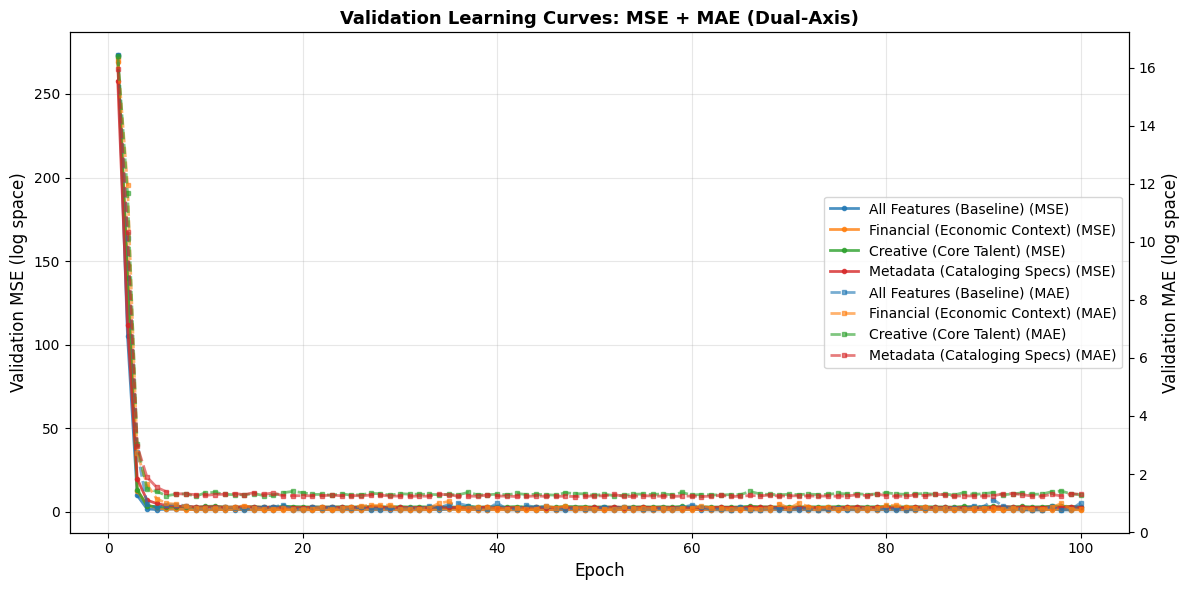

Validation learning curves saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\validation_learning_curves_dual_axis.png


In [11]:
# Plot validation learning curves (MSE + MAE on dual axis)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
color_idx = 0

for group_key, model_info in models.items():
    group_history = results_history[group_key]
    epochs = group_history["epoch"]
    
    # MSE on left axis
    ax1.plot(epochs, group_history["val_mse"], 
            label=f"{model_info['group_name']} (MSE)",
            color=colors[color_idx], linestyle="-", linewidth=2, marker="o", markersize=3, alpha=0.8)
    
    # MAE on right axis (dashed)
    ax2.plot(epochs, group_history["val_mae"],
            label=f"{model_info['group_name']} (MAE)",
            color=colors[color_idx], linestyle="--", linewidth=2, marker="s", markersize=3, alpha=0.6)
    
    color_idx += 1

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Validation MSE (log space)", fontsize=12, color="black")
ax2.set_ylabel("Validation MAE (log space)", fontsize=12, color="black")
ax1.set_title("Validation Learning Curves: MSE + MAE (Dual-Axis)", fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

plt.tight_layout()
plot_path = PLOTS_DIR / "validation_learning_curves_dual_axis.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Validation learning curves saved to {plot_path}")

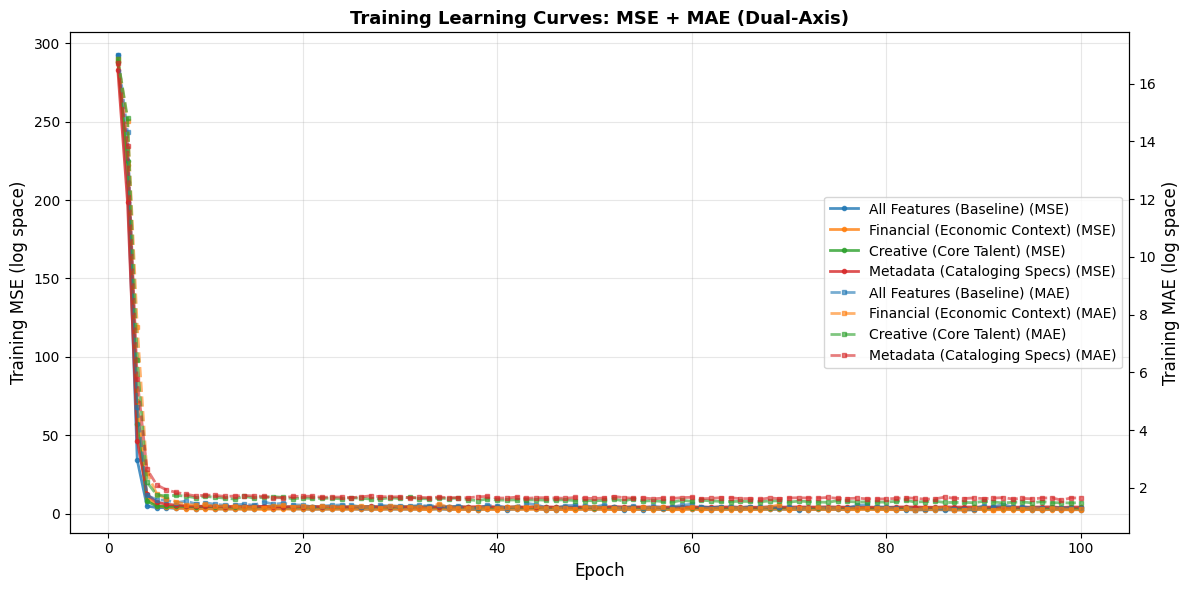

Training learning curves saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\training_learning_curves_dual_axis.png


In [12]:
# Plot training learning curves
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

color_idx = 0
for group_key, model_info in models.items():
    group_history = results_history[group_key]
    epochs = group_history["epoch"]
    
    # MSE on left axis
    ax1.plot(epochs, group_history["train_mse"],
            label=f"{model_info['group_name']} (MSE)",
            color=colors[color_idx], linestyle="-", linewidth=2, marker="o", markersize=3, alpha=0.8)
    
    # MAE on right axis (dashed)
    ax2.plot(epochs, group_history["train_mae"],
            label=f"{model_info['group_name']} (MAE)",
            color=colors[color_idx], linestyle="--", linewidth=2, marker="s", markersize=3, alpha=0.6)
    
    color_idx += 1

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Training MSE (log space)", fontsize=12, color="black")
ax2.set_ylabel("Training MAE (log space)", fontsize=12, color="black")
ax1.set_title("Training Learning Curves: MSE + MAE (Dual-Axis)", fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

plt.tight_layout()
plot_path = PLOTS_DIR / "training_learning_curves_dual_axis.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Training learning curves saved to {plot_path}")

## Results aggregation
Summarize model performance, compute deltas vs baseline, and persist results for reporting.

In [13]:
# Generate summary table
summary_rows = []

baseline_best_mse = None

for group_key, model_info in models.items():
    group_history = results_history[group_key]
    
    # Get best and final metrics
    best_mse_idx = np.argmin(group_history["val_mse"])
    best_mse = group_history["val_mse"][best_mse_idx]
    best_mae = group_history["val_mae"][best_mse_idx]
    
    final_mse = group_history["val_mse"][-1]
    final_mae = group_history["val_mae"][-1]
    
    # Parameter count
    n_params = count_params(model_info["model"])
    
    # Average training time
    avg_time_per_epoch = np.mean(group_history["epoch_time"])
    
    # Store baseline best MSE for delta calculation
    if group_key == "baseline":
        baseline_best_mse = best_mse
    
    summary_rows.append({
        "Model": model_info["group_name"],
        "Best Val MSE": best_mse,
        "Best Val MAE": best_mae,
        "Final Val MSE": final_mse,
        "Final Val MAE": final_mae,
        "Trainable Parameters": n_params,
        "Avg Time/Epoch (s)": avg_time_per_epoch,
        "Input Dim": model_info["input_dim"],
    })

summary_df = pd.DataFrame(summary_rows)

# Calculate delta from baseline
if baseline_best_mse is not None:
    summary_df["MSE Delta from Baseline (%)"] = (
        (summary_df["Best Val MSE"] - baseline_best_mse) / baseline_best_mse * 100
    )

# Save summary table
summary_path = SUMMARIES_DIR / "model_comparison_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\n" + "="*100)
print("MODEL PERFORMANCE SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)
print(f"\nSummary table saved to {summary_path}")


MODEL PERFORMANCE SUMMARY
                       Model  Best Val MSE  Best Val MAE  Final Val MSE  Final Val MAE  Trainable Parameters  Avg Time/Epoch (s)  Input Dim  MSE Delta from Baseline (%)
     All Features (Baseline)      1.076129      0.762503       1.734253       1.011798                192513            0.139083        590                     0.000000
Financial (Economic Context)      1.151092      0.778639       1.175525       0.788842                 64257            0.241204         89                     6.965945
      Creative (Core Talent)      2.689455      1.252991       2.936820       1.286379                162049            0.358578        471                   149.919399
 Metadata (Cataloging Specs)      2.478688      1.225274       2.697619       1.299734                 49153            0.456960         30                   130.333718

Summary table saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding

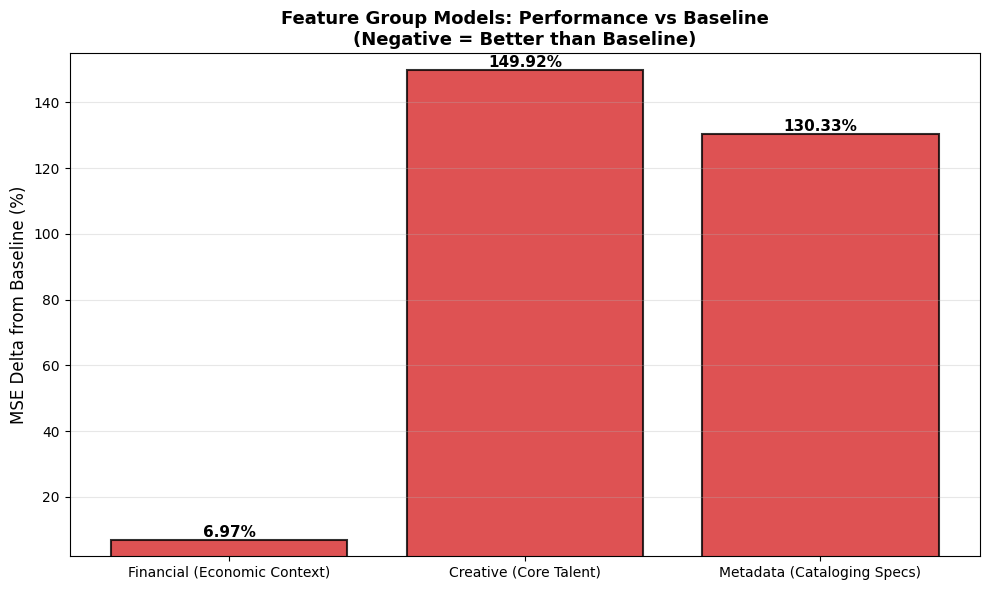

Performance delta plot saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\performance_delta_from_baseline.png


In [14]:
# Plot performance delta from baseline
fig, ax = plt.subplots(figsize=(10, 6))

# Get models excluding baseline
group_names = [name for name in summary_df["Model"] if name != "All Features (Baseline)"]
deltas = summary_df[summary_df["Model"] != "All Features (Baseline)"]["MSE Delta from Baseline (%)"].values

colors_bar = ["#2ca02c" if d < 0 else "#d62728" for d in deltas]

bars = ax.bar(group_names, deltas, color=colors_bar, alpha=0.8, edgecolor="black", linewidth=1.5)

# Add value labels on bars
for bar, delta in zip(bars, deltas):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f"{delta:.2f}%",
            ha="center", va="bottom" if height > 0 else "top", fontsize=11, fontweight="bold")

ax.axhline(y=0, color="black", linestyle="-", linewidth=1.5, label="Baseline")
ax.set_ylabel("MSE Delta from Baseline (%)", fontsize=12)
ax.set_title("Feature Group Models: Performance vs Baseline\n(Negative = Better than Baseline)", 
            fontsize=13, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(bottom=min(deltas) - 5, top=max(deltas) + 5)

plt.tight_layout()
plot_path = PLOTS_DIR / "performance_delta_from_baseline.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Performance delta plot saved to {plot_path}")

## Training history export
Persist per-epoch metrics for reproducibility and later analysis.

In [15]:
# Convert history to DataFrames and save
for group_key, group_history in results_history.items():
    # Create DataFrame from history
    hist_df = pd.DataFrame(group_history)
    
    # Save CSV
    csv_path = HISTORIES_DIR / f"training_history_{group_key}.csv"
    hist_df.to_csv(csv_path, index=False)
    
    # Save NPY (numpy archive)
    npy_path = HISTORIES_DIR / f"training_history_{group_key}.npy"
    np.save(npy_path, group_history)

# Save combined JSON (human-readable summary)
combined_history = {}
for group_key, group_history in results_history.items():
    group_name = FEATURE_GROUPS[group_key]["name"]
    combined_history[group_name] = {
        k: [float(v) if isinstance(v, (np.floating, np.integer)) else v for v in val]
        for k, val in group_history.items()
    }

json_path = HISTORIES_DIR / "all_training_histories.json"
with open(json_path, "w") as f:
    json.dump(combined_history, f, indent=2)

print(f"Training histories saved:")
for group_key in results_history.keys():
    print(f"  - {HISTORIES_DIR / f'training_history_{group_key}.csv'}")
print(f"  - {json_path}")

Training histories saved:
  - c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories\training_history_baseline.csv
  - c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories\training_history_financial.csv
  - c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories\training_history_creative.csv
  - c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories\training_history_metadata.csv
  - c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories\all_training_histories.json


## Ensemble variants
Start with a simple average of feature-group predictions as a baseline ensemble; then explore weighted variants below.


In [16]:
# Baseline vs Feature Group Average Ensemble - Validation Score Comparison
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate average predictions from the three feature groups (excluding baseline)
financial_pred = all_val_predictions["financial"]
creative_pred = all_val_predictions["creative"]
metadata_pred = all_val_predictions["metadata"]
baseline_pred = all_val_predictions["baseline"]
actual_pred = all_val_predictions["actual"]

# Simple average of the three feature groups
avg_ensemble_pred = (financial_pred + creative_pred + metadata_pred) / 3

# Validation metrics (MSE & MAE)
baseline_val_mse = mean_squared_error(actual_pred, baseline_pred)
baseline_val_mae = mean_absolute_error(actual_pred, baseline_pred)

ensemble_val_mse = mean_squared_error(actual_pred, avg_ensemble_pred)
ensemble_val_mae = mean_absolute_error(actual_pred, avg_ensemble_pred)

# Print validation comparison
print("\n" + "="*90)
print("BASELINE vs FEATURE GROUP AVERAGE ENSEMBLE - VALIDATION PERFORMANCE")
print("="*90)
print(f"\nEnsemble Method: Simple Average of (Financial + Creative + Metadata) / 3\n")

print(f"{'Metric':<15} {'Baseline':<18} {'Ensemble':<18} {'Delta (%)':<15}")
print("-" * 70)
val_mse_delta = ((ensemble_val_mse - baseline_val_mse) / baseline_val_mse) * 100
val_mae_delta = ((ensemble_val_mae - baseline_val_mae) / baseline_val_mae) * 100
print(f"{'Validation MSE':<15} {baseline_val_mse:<18.4f} {ensemble_val_mse:<18.4f} {val_mse_delta:+.2f}%")
print(f"{'Validation MAE':<15} {baseline_val_mae:<18.4f} {ensemble_val_mae:<18.4f} {val_mae_delta:+.2f}%")

print("-" * 90)
if ensemble_val_mse < baseline_val_mse:
    improvement = ((baseline_val_mse - ensemble_val_mse) / baseline_val_mse) * 100
    print(f"✓ Ensemble IMPROVES over Baseline by {improvement:.2f}% on Validation MSE")
else:
    degradation = ((ensemble_val_mse - baseline_val_mse) / baseline_val_mse) * 100
    print(f"✗ Ensemble DEGRADES vs Baseline by {degradation:.2f}% on Validation MSE")
print("="*90)



BASELINE vs FEATURE GROUP AVERAGE ENSEMBLE - VALIDATION PERFORMANCE

Ensemble Method: Simple Average of (Financial + Creative + Metadata) / 3

Metric          Baseline           Ensemble           Delta (%)      
----------------------------------------------------------------------
Validation MSE  1.0761             1.5450             +43.57%
Validation MAE  0.7625             0.9193             +20.57%
------------------------------------------------------------------------------------------
✗ Ensemble DEGRADES vs Baseline by 43.57% on Validation MSE


## Ensemble variants: calculated weights
Derive performance-based weights from earlier deltas and evaluate the weighted ensemble on validation data.


In [17]:
# Calculate performance-based weights from Section 9 summary
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Extract deltas from summary_df for feature groups only (excluding baseline)
feature_groups_summary = summary_df[summary_df["Model"] != "All Features (Baseline)"].copy()

# Get the performance deltas (negative = better, positive = worse)
financial_delta = feature_groups_summary[feature_groups_summary["Model"].str.contains("Financial")]["MSE Delta from Baseline (%)"].values[0]
creative_delta = feature_groups_summary[feature_groups_summary["Model"].str.contains("Creative")]["MSE Delta from Baseline (%)"].values[0]
metadata_delta = feature_groups_summary[feature_groups_summary["Model"].str.contains("Metadata")]["MSE Delta from Baseline (%)"].values[0]

# Convert deltas to performance scores using exponential decay
# Higher delta (worse performance) gets exponentially lower weight
# Formula: weight ∝ exp(-delta / 100)
deltas = np.array([financial_delta, creative_delta, metadata_delta])

# Apply exponential decay: exp(-delta/100)
# This keeps all weights positive even for large positive deltas
performance_scores = np.exp(-deltas / 100)

# Normalize to weights (sum to 1)
calculated_weights = performance_scores / performance_scores.sum()

print("\n" + "="*90)
print("SECTION 12: CALCULATED WEIGHTED ENSEMBLE (EXPONENTIAL DECAY WEIGHTS)")
print("="*90)
print(f"\nPerformance Deltas from Section 9 (MSE vs Baseline):")
print(f"  Financial: {financial_delta:+.2f}%")
print(f"  Creative:  {creative_delta:+.2f}%")
print(f"  Metadata:  {metadata_delta:+.2f}%")

print(f"\nExponential Decay Scores (exp(-delta/100)):")
print(f"  Financial: {performance_scores[0]:.6f}")
print(f"  Creative:  {performance_scores[1]:.6f}")
print(f"  Metadata:  {performance_scores[2]:.6f}")

print(f"\nCalculated Weights (normalized to sum=1):")
print(f"  Financial: {calculated_weights[0]:.4f}")
print(f"  Creative:  {calculated_weights[1]:.4f}")
print(f"  Metadata:  {calculated_weights[2]:.4f}")
print(f"  Sum:       {calculated_weights.sum():.4f}")

# Apply calculated weights to get ensemble predictions
financial_pred_val = all_val_predictions["financial"]
creative_pred_val = all_val_predictions["creative"]
metadata_pred_val = all_val_predictions["metadata"]
baseline_pred_val = all_val_predictions["baseline"]
actual_val = all_val_predictions["actual"]

calculated_weighted_ensemble_pred = (
    calculated_weights[0] * financial_pred_val +
    calculated_weights[1] * creative_pred_val +
    calculated_weights[2] * metadata_pred_val
)

# Calculate metrics
baseline_val_mse = mean_squared_error(actual_val, baseline_pred_val)
baseline_val_mae = mean_absolute_error(actual_val, baseline_pred_val)

calc_weighted_val_mse = mean_squared_error(actual_val, calculated_weighted_ensemble_pred)
calc_weighted_val_mae = mean_absolute_error(actual_val, calculated_weighted_ensemble_pred)

# Compare
print(f"\nValidation Performance Comparison:")
print(f"{'Metric':<15} {'Baseline':<18} {'Calc Weighted':<18} {'Delta (%)':<15}")
print("-" * 70)
calc_mse_delta = ((calc_weighted_val_mse - baseline_val_mse) / baseline_val_mse) * 100
calc_mae_delta = ((calc_weighted_val_mae - baseline_val_mae) / baseline_val_mae) * 100
print(f"{'Validation MSE':<15} {baseline_val_mse:<18.4f} {calc_weighted_val_mse:<18.4f} {calc_mse_delta:+.2f}%")
print(f"{'Validation MAE':<15} {baseline_val_mae:<18.4f} {calc_weighted_val_mae:<18.4f} {calc_mae_delta:+.2f}%")

print("-" * 90)
if calc_weighted_val_mse < baseline_val_mse:
    improvement = ((baseline_val_mse - calc_weighted_val_mse) / baseline_val_mse) * 100
    print(f"✓ Calculated Weighted Ensemble IMPROVES over Baseline by {improvement:.2f}%")
else:
    degradation = ((calc_weighted_val_mse - baseline_val_mse) / baseline_val_mse) * 100
    print(f"✗ Calculated Weighted Ensemble DEGRADES vs Baseline by {degradation:.2f}%")
print("="*90)



SECTION 12: CALCULATED WEIGHTED ENSEMBLE (EXPONENTIAL DECAY WEIGHTS)

Performance Deltas from Section 9 (MSE vs Baseline):
  Financial: +6.97%
  Creative:  +149.92%
  Metadata:  +130.33%

Exponential Decay Scores (exp(-delta/100)):
  Financial: 0.932711
  Creative:  0.223310
  Metadata:  0.271624

Calculated Weights (normalized to sum=1):
  Financial: 0.6533
  Creative:  0.1564
  Metadata:  0.1903
  Sum:       1.0000

Validation Performance Comparison:
Metric          Baseline           Calc Weighted      Delta (%)      
----------------------------------------------------------------------
Validation MSE  1.0761             1.1940             +10.95%
Validation MAE  0.7625             0.7838             +2.79%
------------------------------------------------------------------------------------------
✗ Calculated Weighted Ensemble DEGRADES vs Baseline by 10.95%


## Ensemble variants: learned weights (frozen models)
Learn softmax-normalized weights over frozen model predictions using validation loss.

In [18]:
# =========================
# SECTION 13
# =========================
print("\n" + "="*90)
print("SECTION 13: LEARNED WEIGHTED ENSEMBLE (SOFTMAX-NORMALIZED WEIGHTS)")
print("="*90)

import torch
import torch.nn as nn
import torch.optim as optim

# 1) Use your existing trained models and their val predictions:
# financial_pred_val, creative_pred_val, metadata_pred_val, actual_val
# (these already exist in your notebook)

financial_val_tensor = torch.tensor(financial_pred_val, dtype=torch.float32).unsqueeze(1).to(device)
creative_val_tensor  = torch.tensor(creative_pred_val, dtype=torch.float32).unsqueeze(1).to(device)
metadata_val_tensor  = torch.tensor(metadata_pred_val, dtype=torch.float32).unsqueeze(1).to(device)
actual_val_tensor    = torch.tensor(actual_val, dtype=torch.float32).to(device)

X_ensemble_val = torch.cat([financial_val_tensor, creative_val_tensor, metadata_val_tensor], dim=1)  # (N,3)

class SoftmaxWeightedEnsemble(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw_weights_param = nn.Parameter(torch.randn(3))

    def forward(self, x):
        w = torch.softmax(self.raw_weights_param, dim=0)  # (3,)
        return torch.sum(x * w, dim=1)  # (N,)

neuron_model = SoftmaxWeightedEnsemble().to(device)
optimizer = optim.AdamW(neuron_model.parameters(), lr=1e-2, weight_decay=1e-5)
criterion = nn.MSELoss()

num_epochs_neuron = 100
neuron_losses = []

for epoch in range(num_epochs_neuron):
    neuron_model.train()
    optimizer.zero_grad(set_to_none=True)

    pred = neuron_model(X_ensemble_val)
    loss = criterion(pred, actual_val_tensor)

    loss.backward()
    optimizer.step()

    neuron_losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs_neuron}: Loss = {loss.item():.6f}")

with torch.no_grad():
    learned_weights = torch.softmax(neuron_model.raw_weights_param, dim=0).detach().cpu().numpy()

print(f"\nLearned Weights (softmax-normalized, sum=1):")
print(f"  Financial: {learned_weights[0]:.4f}")
print(f"  Creative:  {learned_weights[1]:.4f}")
print(f"  Metadata:  {learned_weights[2]:.4f}")
print(f"  Sum:       {learned_weights.sum():.4f}")

# Ensemble prediction on val (same arrays as before)
learned_weighted_ensemble_pred = (
    learned_weights[0] * financial_pred_val +
    learned_weights[1] * creative_pred_val +
    learned_weights[2] * metadata_pred_val
)

# If you already computed baseline_val_mse / baseline_val_mae earlier, keep using them.
# Otherwise compute here as you did before.
learned_weighted_val_mse = mean_squared_error(actual_val, learned_weighted_ensemble_pred)
learned_weighted_val_mae = mean_absolute_error(actual_val, learned_weighted_ensemble_pred)

print(f"\nSection 13 Validation:")
print(f"  MSE = {learned_weighted_val_mse:.6f}")
print(f"  MAE = {learned_weighted_val_mae:.6f}")



SECTION 13: LEARNED WEIGHTED ENSEMBLE (SOFTMAX-NORMALIZED WEIGHTS)
Epoch  20/100: Loss = 1.224668
Epoch  40/100: Loss = 1.172124
Epoch  60/100: Loss = 1.146563
Epoch  80/100: Loss = 1.134671
Epoch 100/100: Loss = 1.128886

Learned Weights (softmax-normalized, sum=1):
  Financial: 0.7971
  Creative:  0.0525
  Metadata:  0.1504
  Sum:       1.0000

Section 13 Validation:
  MSE = 1.128687
  MAE = 0.760265


## Ensemble variants: joint training
Train the group models and the ensemble neuron together to observe adaptive weighting over epochs.

In [ ]:
# =========================
# SECTION 14
# =========================
print("\n" + "="*100)
print("SECTION 14: JOINT TRAINING (MODELS + ENSEMBLE NEURON TOGETHER)")
print("="*100)

import torch
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
import time

# 1) Reinitialize models (fresh start) — match baseline architecture
joint_models = {}
for group_key, group_config in FEATURE_GROUPS.items():
    loader_info = data_loaders[group_key]
    input_dim = loader_info["input_dim"]

    model = TabularRegressor(
        mode="shared",
        input_dim=input_dim,
        encoder_hidden=BASELINE_ENCODER_HIDDEN,
        head_hidden=BASELINE_HEAD_HIDDEN,
        dropout=BASELINE_DROPOUT,
    ).to(device)

    joint_models[group_key] = {
        "model": model,
        "group_name": group_config["name"],
        "input_dim": input_dim,
    }

# 2) Neuron (same as Sec 13)
class SoftmaxWeightedEnsemble(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw_weights_param = nn.Parameter(torch.randn(3))

    def forward(self, x):
        w = torch.softmax(self.raw_weights_param, dim=0)
        return torch.sum(x * w, dim=1)

joint_neuron_model = SoftmaxWeightedEnsemble().to(device)

# 3) One optimizer for EVERYTHING (models + neuron) — key fix
JOINT_EPOCHS = 100
NEURON_LR = 1e-3  # keep your intent: neuron slightly smaller LR
criterion = nn.MSELoss()

# Build param groups: models at LEARNING_RATE, neuron at NEURON_LR
param_groups = []
for g in ["financial", "creative", "metadata"]:
    param_groups.append({"params": joint_models[g]["model"].parameters(), "lr": LEARNING_RATE})
param_groups.append({"params": joint_neuron_model.parameters(), "lr": NEURON_LR})

joint_optimizer = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)

# Tracking (same spirit as yours)
neuron_weight_history = {
    "epoch": [],
    "financial_weight": [],
    "creative_weight": [],
    "metadata_weight": [],
    "ensemble_val_mse": [],
    "ensemble_val_mae": [],
}

best_ensemble_val_mse = float("inf")
best_checkpoint_path = CHECKPOINTS_DIR / "joint_ensemble_best.pt"
best_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

# Helper: forward ensemble for a batch
def forward_ensemble_batch(X_fin, X_cre, X_meta):
    p_fin = joint_models["financial"]["model"](X_fin).squeeze()
    p_cre = joint_models["creative"]["model"](X_cre).squeeze()
    p_met = joint_models["metadata"]["model"](X_meta).squeeze()
    stacked = torch.stack([p_fin, p_cre, p_met], dim=1)  # (B,3)
    y_hat = joint_neuron_model(stacked)                  # (B,)
    return y_hat

# IMPORTANT: joint training requires aligned batches across loaders.
# This assumes your loaders are aligned (same shuffle/ordering). If not, set shuffle=False for all.
train_loaders = {
    g: data_loaders[g]["train_loader"] for g in ["financial", "creative", "metadata"]
}
val_tensors = {
    g: val_tensors_by_group[g][0].to(device) for g in ["financial", "creative", "metadata"]
}
y_val_tensor = val_tensors_by_group["financial"][1].to(device).float()  # assume same y for all

for epoch in range(1, JOINT_EPOCHS + 1):
    t0 = time.time()
    joint_neuron_model.train()
    for g in ["financial", "creative", "metadata"]:
        joint_models[g]["model"].train()

    # ---- Train epoch: zip loaders and backprop on ensemble loss ----
    running_loss = 0.0
    n_seen = 0

    for (Xf, yf), (Xc, yc), (Xm, ym) in zip(train_loaders["financial"],
                                            train_loaders["creative"],
                                            train_loaders["metadata"]):
        # Ensure targets are aligned
        # (if this fails, your loaders are not aligned -> must disable shuffle or build a unified loader)
        if not torch.allclose(yf.float(), yc.float()) or not torch.allclose(yf.float(), ym.float()):
            raise RuntimeError("Targets mismatch across loaders in joint training. "
                               "Your loaders are not aligned. Set shuffle=False and ensure same ordering.")

        Xf = Xf.to(device)
        Xc = Xc.to(device)
        Xm = Xm.to(device)
        y  = yf.to(device).float()

        joint_optimizer.zero_grad(set_to_none=True)
        y_hat = forward_ensemble_batch(Xf, Xc, Xm)
        loss = criterion(y_hat, y)
        loss.backward()
        joint_optimizer.step()

        bs = y.shape[0]
        running_loss += loss.item() * bs
        n_seen += bs

    # ---- Validate ensemble on full val tensors (no numpy) ----
    joint_neuron_model.eval()
    for g in ["financial", "creative", "metadata"]:
        joint_models[g]["model"].eval()

    with torch.no_grad():
        y_val_hat = forward_ensemble_batch(val_tensors["financial"], val_tensors["creative"], val_tensors["metadata"])
        ensemble_val_mse = torch.mean((y_val_hat - y_val_tensor) ** 2).item()
        ensemble_val_mae = torch.mean(torch.abs(y_val_hat - y_val_tensor)).item()

        w = torch.softmax(joint_neuron_model.raw_weights_param, dim=0).detach().cpu().numpy()

    neuron_weight_history["epoch"].append(epoch)
    neuron_weight_history["financial_weight"].append(float(w[0]))
    neuron_weight_history["creative_weight"].append(float(w[1]))
    neuron_weight_history["metadata_weight"].append(float(w[2]))
    neuron_weight_history["ensemble_val_mse"].append(ensemble_val_mse)
    neuron_weight_history["ensemble_val_mae"].append(ensemble_val_mae)

    # ---- Save best ENSEMBLE checkpoint (models + neuron together) ----
    if ensemble_val_mse < best_ensemble_val_mse:
        best_ensemble_val_mse = ensemble_val_mse
        torch.save({
            "financial": joint_models["financial"]["model"].state_dict(),
            "creative":  joint_models["creative"]["model"].state_dict(),
            "metadata":  joint_models["metadata"]["model"].state_dict(),
            "neuron":    joint_neuron_model.state_dict(),
            "epoch":     epoch,
            "val_mse":   ensemble_val_mse,
            "val_mae":   ensemble_val_mae,
        }, best_checkpoint_path)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{JOINT_EPOCHS} | "
              f"train_loss={running_loss/max(n_seen,1):.6f} | "
              f"val_mse={ensemble_val_mse:.6f} | val_mae={ensemble_val_mae:.6f} | "
              f"w=[{w[0]:.3f},{w[1]:.3f},{w[2]:.3f}] | "
              f"time={time.time()-t0:.1f}s")

print(f"\n✓ Joint training done. Best ensemble val MSE = {best_ensemble_val_mse:.6f}")
print(f"Best checkpoint saved to: {best_checkpoint_path}")

# ---- Load best ensemble and compute final val metrics ----
ckpt = torch.load(best_checkpoint_path, map_location=device)
joint_models["financial"]["model"].load_state_dict(ckpt["financial"])
joint_models["creative"]["model"].load_state_dict(ckpt["creative"])
joint_models["metadata"]["model"].load_state_dict(ckpt["metadata"])
joint_neuron_model.load_state_dict(ckpt["neuron"])

joint_neuron_model.eval()
for g in ["financial", "creative", "metadata"]:
    joint_models[g]["model"].eval()

with torch.no_grad():
    y_val_hat = forward_ensemble_batch(val_tensors["financial"], val_tensors["creative"], val_tensors["metadata"])
    joint_ensemble_mse = torch.mean((y_val_hat - y_val_tensor) ** 2).item()
    joint_ensemble_mae = torch.mean(torch.abs(y_val_hat - y_val_tensor)).item()
    joint_learned_weights = torch.softmax(joint_neuron_model.raw_weights_param, dim=0).detach().cpu().numpy()

print("\n" + "-"*100)
print("SECTION 14 FINAL (Best Ensemble Checkpoint)")
print("-"*100)
print(f"  Learned Weights: Financial={joint_learned_weights[0]:.4f} | Creative={joint_learned_weights[1]:.4f} | Metadata={joint_learned_weights[2]:.4f}")
print(f"  Ensemble Val MSE = {joint_ensemble_mse:.6f}")
print(f"  Ensemble Val MAE = {joint_ensemble_mae:.6f}")
print("-"*100)



SECTION 14: JOINT TRAINING (MODELS + ENSEMBLE NEURON TOGETHER)


c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch   1/100 | train_loss=290.127156 | val_mse=272.206512 | val_mae=16.401604 | w=[0.180,0.545,0.275] | time=0.4s
Epoch  10/100 | train_loss=2.337877 | val_mse=1.644768 | val_mae=0.954186 | w=[0.180,0.536,0.284] | time=0.3s
Epoch  20/100 | train_loss=1.735562 | val_mse=1.255721 | val_mae=0.827283 | w=[0.183,0.535,0.282] | time=0.3s
Epoch  30/100 | train_loss=1.542574 | val_mse=1.170569 | val_mae=0.802316 | w=[0.186,0.533,0.282] | time=0.3s
Epoch  40/100 | train_loss=1.431472 | val_mse=1.080685 | val_mae=0.757524 | w=[0.187,0.531,0.282] | time=0.4s
Epoch  50/100 | train_loss=1.328652 | val_mse=1.037769 | val_mae=0.741179 | w=[0.189,0.529,0.282] | time=0.3s
Epoch  60/100 | train_loss=1.281553 | val_mse=1.077934 | val_mae=0.761083 | w=[0.189,0.529,0.282] | time=0.3s
Epoch  70/100 | train_loss=1.247661 | val_mse=1.091635 | val_mae=0.765444 | w=[0.190,0.528,0.282] | time=0.3s
Epoch  80/100 | train_loss=1.210736 | val_mse=1.092612 | val_mae=0.764413 | w=[0.190,0.528,0.282] | time=0.3s
Epoch

## Fusion experiments: frozen encoders
Freeze group encoders, concatenate their 64-d representations, and train a fusion head on top.


In [ ]:
# =========================
# SECTION 15
# =========================
# FUSION AFTER 64 (FROZEN GROUP ENCODERS)
#
# Goal:
# - We keep the exact baseline encoder architecture (from baseline artifacts) for each group model.
# - We take the 64-d output from each group's encoder (financial, creative, metadata),
#   concatenate them to 192-d, and train a small fusion head to predict GROSS.
#
# Key constraint (Frozen Encoders):
# - The group encoders are frozen (no gradient flows into them).
# - Only the fusion head is trained.
#
# Validation protocol:
# - Train fusion head on TRAIN batches.
# - Evaluate fusion head on the VALIDATION set ONLY (same as other models here).
#
# NOTE:
# - In this notebook, TabularRegressor exposes `model.encoder(x)` and `model.head(h)`.
# - The encoder output dimension is 64 (per your baseline architecture).
# - `val_tensors_by_group[group_key]` already exists from Section 6 prep.

print("\n" + "="*100)
print("SECTION 15: FUSION AFTER 64 (FROZEN GROUP ENCODERS)")
print("="*100)

import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path

# ----------------------------
# 0) Setup paths and check dependencies
# ----------------------------
# Define checkpoint directory if not already defined
if 'CHECKPOINTS_DIR' not in globals():
    NOTEBOOK_DIR = Path(".")
    ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "seperated_vs_shared_encoding"
    ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR = ARTIFACT_ROOT
    CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"
    CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
    print(f"CHECKPOINTS_DIR defined: {CHECKPOINTS_DIR.absolute()}")

# Check if previous sections were run
required_vars = ['models', 'data_loaders', 'val_tensors_by_group', 'device']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print(f"\n⚠️  ERROR: Missing required variables from previous sections: {missing_vars}")
    print(f"\n📋 To fix this, you must run the following sections first:")
    print(f"   - Section 2: Imports and device setup (for 'device')")
    print(f"   - Section 4: Create group loaders (for 'data_loaders')")
    print(f"   - Section 5: Initialize models (for 'models')")
    print(f"   - Section 6: Training loop (for 'val_tensors_by_group')")
    print(f"\nCannot proceed without these variables.")
    raise RuntimeError(f"Missing required variables: {missing_vars}. Please run earlier sections first.")

print(f"✓ All required variables found")

# ----------------------------
# 1) Convenience references
# ----------------------------
FUSION_GROUPS = ["financial", "creative", "metadata"]

# Make sure best checkpoints exist and load them (important so fusion uses best encoders)
print(f"\nLoading best checkpoints for fusion groups...")
for g in FUSION_GROUPS:
    ckpt_path = CHECKPOINTS_DIR / f"{g}_best.pt"
    if ckpt_path.exists():
        models[g]["model"].load_state_dict(torch.load(ckpt_path, map_location=device))
        print(f"  ✓ Loaded {g} from {ckpt_path.name}")
    else:
        print(f"  ⚠️  WARNING: No checkpoint found for {g} at {ckpt_path}")
        print(f"     Using current model state (may not be optimal)")
    models[g]["model"].to(device)

# ----------------------------
# 2) Freeze encoders
# ----------------------------
encoders = {}
for g in FUSION_GROUPS:
    m = models[g]["model"]
    m.eval()  # safe: we want stable encoders (no dropout noise)
    # Freeze ONLY the encoder (head doesn't matter; we won't use it)
    for p in m.encoder.parameters():
        p.requires_grad = False
    encoders[g] = m.encoder

print(f"\n✓ Frozen encoders for: {FUSION_GROUPS}")

# ----------------------------
# 3) Fusion head (192 -> 1)
# ----------------------------
class FusionHead(nn.Module):
    def __init__(self, in_dim=192):
        super().__init__()
        # Direct linear layer: 192 -> 1 (no hidden layer)
        self.net = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.net(x)

fusion_head = FusionHead(in_dim=64 * 3).to(device)
print(f"\n✓ Fusion head architecture: 192 -> 1 (direct linear)")

criterion_fusion = nn.MSELoss()
optimizer_fusion = optim.Adam(fusion_head.parameters(), lr=1e-3, weight_decay=0.0)

FUSION_EPOCHS = 100  # can change; doesn't affect other sections
print(f"✓ Fusion training epochs: {FUSION_EPOCHS}")

# ----------------------------
# 4) Prepare train and val data
# ----------------------------
fusion_history = {
    "epoch": [],
    "train_mse": [],
    "train_mae": [],
    "val_mse": [],
    "val_mae": [],
}

best_fusion_val_mse = float("inf")
best_fusion_state = None

def mae_from_preds(pred, y):
    return torch.mean(torch.abs(pred - y))

# Train loaders for groups (these yield (X, y))
train_loader_fin  = data_loaders["financial"]["train_loader"]
train_loader_cre  = data_loaders["creative"]["train_loader"]
train_loader_meta = data_loaders["metadata"]["train_loader"]

# Validation tensors for groups (val_tensors_by_group is a tuple (X_tensor, y_tensor) from Section 6)
Xv_fin, yv_fin = val_tensors_by_group["financial"]
Xv_fin = Xv_fin.to(device)
yv_fin = yv_fin.to(device).view(-1, 1)

Xv_cre, yv_cre = val_tensors_by_group["creative"]
Xv_cre = Xv_cre.to(device)
yv_cre = yv_cre.to(device).view(-1, 1)

Xv_meta, yv_meta = val_tensors_by_group["metadata"]
Xv_meta = Xv_meta.to(device)
yv_meta = yv_meta.to(device).view(-1, 1)

# Sanity: val targets should be identical across groups (they are built from same y_val)
if not torch.equal(yv_fin, yv_cre) or not torch.equal(yv_fin, yv_meta):
    raise RuntimeError("Validation targets not aligned across groups. Something is inconsistent in val_tensors_by_group.")

y_val_fusion = yv_fin  # single reference

print(f"\n✓ Validation set sizes: fin={Xv_fin.shape}, cre={Xv_cre.shape}, meta={Xv_meta.shape}")

# ----------------------------
# 5) Define validation evaluation function
# ----------------------------
@torch.no_grad()
def eval_fusion_on_val():
    fusion_head.eval()

    # Frozen encoders -> embeddings
    h_fin  = encoders["financial"](Xv_fin)     # [N,64]
    h_cre  = encoders["creative"](Xv_cre)      # [N,64]
    h_meta = encoders["metadata"](Xv_meta)     # [N,64]

    h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # [N,192]
    pred = fusion_head(h)                         # [N,1]

    mse = criterion_fusion(pred, y_val_fusion).item()
    mae = torch.mean(torch.abs(pred - y_val_fusion)).item()
    return mse, mae

# ----------------------------
# 6) Training loop
# ----------------------------
print(f"\n{'='*100}")
print(f"Starting fusion training...")
print(f"{'='*100}\n")

for epoch in range(1, FUSION_EPOCHS + 1):
    fusion_head.train()
    train_mse_sum = 0.0
    train_mae_sum = 0.0
    n_train = 0

    # zip group train loaders — they should be aligned because shuffle=False everywhere in your loaders
    for (x_fin, y_fin), (x_cre, y_cre), (x_meta, y_meta) in zip(train_loader_fin, train_loader_cre, train_loader_meta):
        x_fin  = x_fin.to(device, non_blocking=True)
        x_cre  = x_cre.to(device, non_blocking=True)
        x_meta = x_meta.to(device, non_blocking=True)

        y_fin  = y_fin.to(device, non_blocking=True).view(-1, 1)
        y_cre  = y_cre.to(device, non_blocking=True).view(-1, 1)
        y_meta = y_meta.to(device, non_blocking=True).view(-1, 1)

        # Ensure targets aligned across group batches (should be true)
        if not torch.equal(y_fin, y_cre) or not torch.equal(y_fin, y_meta):
            raise RuntimeError("Train targets not aligned across group loaders. Ensure same ordering and shuffle=False.")

        y = y_fin

        # Build frozen embeddings (no grad into encoders)
        with torch.no_grad():
            h_fin  = encoders["financial"](x_fin)   # [B,64]
            h_cre  = encoders["creative"](x_cre)    # [B,64]
            h_meta = encoders["metadata"](x_meta)   # [B,64]
            h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # [B,192]

        pred = fusion_head(h)
        loss = criterion_fusion(pred, y)

        optimizer_fusion.zero_grad()
        loss.backward()
        optimizer_fusion.step()

        bs = y.size(0)
        train_mse_sum += loss.item() * bs
        train_mae_sum += mae_from_preds(pred.detach(), y).item() * bs
        n_train += bs

    train_mse = train_mse_sum / max(1, n_train)
    train_mae = train_mae_sum / max(1, n_train)

    # Validation (full val, like your other eval path)
    val_mse, val_mae = eval_fusion_on_val()

    fusion_history["epoch"].append(epoch)
    fusion_history["train_mse"].append(train_mse)
    fusion_history["train_mae"].append(train_mae)
    fusion_history["val_mse"].append(val_mse)
    fusion_history["val_mae"].append(val_mae)

    if epoch == 1 or epoch % 10 == 0 or epoch == FUSION_EPOCHS:
        print(f"Epoch {epoch:03d}/{FUSION_EPOCHS} | train MSE {train_mse:.6f} MAE {train_mae:.6f} | val MSE {val_mse:.6f} MAE {val_mae:.6f}")

    if val_mse < best_fusion_val_mse:
        best_fusion_val_mse = val_mse
        best_fusion_state = {k: v.detach().cpu().clone() for k, v in fusion_head.state_dict().items()}

# ----------------------------
# 7) Restore best and report results
# ----------------------------
# restore best fusion head
if best_fusion_state is not None:
    fusion_head.load_state_dict(best_fusion_state)

final_fusion_val_mse, final_fusion_val_mae = eval_fusion_on_val()

print("\n" + "="*100)
print("FUSION TRAINING COMPLETE")
print("="*100)
print(f"Best Fusion Val MSE:  {best_fusion_val_mse:.6f}")
print(f"Final Val MSE:        {final_fusion_val_mse:.6f}")
print(f"Final Val MAE:        {final_fusion_val_mae:.6f}")
print("="*100)

# Store for Section 16 comparison (validation only)
# Keep naming consistent with your other tracking variables/dicts.
fusion64_frozen_metrics = {
    "val_mse": final_fusion_val_mse,
    "val_mae": final_fusion_val_mae,
}

print(f"\n✓ Section 15 complete. Fusion metrics stored in 'fusion64_frozen_metrics'.")


SECTION 15: FUSION AFTER 64 (FROZEN GROUP ENCODERS)
✓ All required variables found

Loading best checkpoints for fusion groups...
  ✓ Loaded financial from financial_best.pt
  ✓ Loaded creative from creative_best.pt
  ✓ Loaded metadata from metadata_best.pt

✓ Frozen encoders for: ['financial', 'creative', 'metadata']

✓ Fusion head architecture: 192 -> 1 (direct linear)
✓ Fusion training epochs: 100

✓ Validation set sizes: fin=torch.Size([815, 89]), cre=torch.Size([815, 471]), meta=torch.Size([815, 30])

Starting fusion training...

Epoch 001/100 | train MSE 183.324061 MAE 13.240603 | val MSE 88.026123 MAE 9.256221
Epoch 010/100 | train MSE 1.722460 MAE 0.959991 | val MSE 1.645440 MAE 0.964115
Epoch 020/100 | train MSE 1.695298 MAE 0.953291 | val MSE 1.621017 MAE 0.956201
Epoch 030/100 | train MSE 1.660919 MAE 0.942085 | val MSE 1.589273 MAE 0.944920
Epoch 040/100 | train MSE 1.621179 MAE 0.928950 | val MSE 1.552834 MAE 0.931674
Epoch 050/100 | train MSE 1.577817 MAE 0.914439 | val 

## Fusion experiments: joint (end-to-end)
Train group encoders and the fusion head together so gradients flow through the full stack.

In [ ]:
# =========================
# SECTION 16
# =========================
# JOINT FUSION AT 64 (UNFROZEN ENCODERS - END-TO-END TRAINING)
#
# Goal:
# - Train 3 separate group encoders (256 -> 128 -> 64) jointly with a fusion head (192 -> 1)
# - All encoders are trainable (NOT frozen)
# - Gradients flow back through the fusion head into all encoders
# - This is end-to-end joint training from scratch
#
# Difference from Section 15:
# - Section 15: Encoders are frozen, only fusion head trains
# - Section 16: Everything trains jointly (encoders + fusion head)

print("\n" + "="*100)
print("SECTION 16: JOINT FUSION AT 64 (UNFROZEN ENCODERS - END-TO-END TRAINING)")
print("="*100)

import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path

# ----------------------------
# 1) Create fresh encoders (don't use pre-trained ones)
# ----------------------------
FUSION_GROUPS = ["financial", "creative", "metadata"]

# Create new encoder models (separate from the pre-trained ones)
joint_fusion_encoders = {}

for g in FUSION_GROUPS:
    # Get input dimension from data_loaders
    input_dim = data_loaders[g]["input_dim"]
    
    # Create a fresh encoder with baseline architecture
    encoder_model = TabularRegressor(
        mode="shared",
        input_dim=input_dim,
        encoder_hidden=BASELINE_ENCODER_HIDDEN,
        head_hidden=BASELINE_HEAD_HIDDEN,
        dropout=BASELINE_DROPOUT,
    ).to(device)
    
    joint_fusion_encoders[g] = {
        "model": encoder_model,
        "input_dim": input_dim,
    }

print(f"\n✓ Created fresh encoders for joint training: {FUSION_GROUPS}")
for g in FUSION_GROUPS:
    print(f"   {g}: input_dim={joint_fusion_encoders[g]['input_dim']}")

# ----------------------------
# 2) Create fusion head (192 -> 1)
# ----------------------------
class JointFusionHead(nn.Module):
    def __init__(self, in_dim=192):
        super().__init__()
        # Direct linear layer: 192 -> 1
        self.net = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.net(x)

joint_fusion_head = JointFusionHead(in_dim=64 * 3).to(device)
print(f"\n✓ Joint fusion head architecture: 192 -> 1 (direct linear)")

# ----------------------------
# 3) Setup training
# ----------------------------
criterion_joint = nn.MSELoss()

# Collect all parameters (encoders + fusion head) for joint optimization
all_params = []
for g in FUSION_GROUPS:
    all_params.extend(joint_fusion_encoders[g]["model"].parameters())
all_params.extend(joint_fusion_head.parameters())

optimizer_joint_fusion = optim.AdamW(all_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

JOINT_FUSION_EPOCHS = 100
print(f"✓ Joint fusion training epochs: {JOINT_FUSION_EPOCHS}")

joint_fusion_history = {
    "epoch": [],
    "train_mse": [],
    "train_mae": [],
    "val_mse": [],
    "val_mae": [],
}

best_joint_fusion_val_mse = float("inf")
best_joint_fusion_state = None

def mae_metric(pred, y):
    return torch.mean(torch.abs(pred - y))

# Train loaders
train_loader_fin  = data_loaders["financial"]["train_loader"]
train_loader_cre  = data_loaders["creative"]["train_loader"]
train_loader_meta = data_loaders["metadata"]["train_loader"]

# Validation tensors
Xv_fin, yv_fin = val_tensors_by_group["financial"]
Xv_fin = Xv_fin.to(device)
yv_fin = yv_fin.to(device).view(-1, 1)

Xv_cre, yv_cre = val_tensors_by_group["creative"]
Xv_cre = Xv_cre.to(device)
yv_cre = yv_cre.to(device).view(-1, 1)

Xv_meta, yv_meta = val_tensors_by_group["metadata"]
Xv_meta = Xv_meta.to(device)
yv_meta = yv_meta.to(device).view(-1, 1)

y_val_joint = yv_fin

print(f"\n✓ Validation set sizes: fin={Xv_fin.shape}, cre={Xv_cre.shape}, meta={Xv_meta.shape}")

# ----------------------------
# 4) Validation evaluation function
# ----------------------------
@torch.no_grad()
def eval_joint_fusion_on_val():
    # Set all models to eval mode
    for g in FUSION_GROUPS:
        joint_fusion_encoders[g]["model"].eval()
    joint_fusion_head.eval()

    # Get 64-d representations from encoders
    h_fin  = joint_fusion_encoders["financial"]["model"].encoder(Xv_fin)   # [N,64]
    h_cre  = joint_fusion_encoders["creative"]["model"].encoder(Xv_cre)    # [N,64]
    h_meta = joint_fusion_encoders["metadata"]["model"].encoder(Xv_meta)   # [N,64]

    # Fuse
    h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # [N,192]
    pred = joint_fusion_head(h)                    # [N,1]

    mse = criterion_joint(pred, y_val_joint).item()
    mae = torch.mean(torch.abs(pred - y_val_joint)).item()
    return mse, mae

# ----------------------------
# 5) Training loop
# ----------------------------
print(f"\n{'='*100}")
print(f"Starting joint fusion training (end-to-end)...")
print(f"{'='*100}\n")

for epoch in range(1, JOINT_FUSION_EPOCHS + 1):
    # Set all models to train mode
    for g in FUSION_GROUPS:
        joint_fusion_encoders[g]["model"].train()
    joint_fusion_head.train()

    train_mse_sum = 0.0
    train_mae_sum = 0.0
    n_train = 0

    # Zip group train loaders
    for (x_fin, y_fin), (x_cre, y_cre), (x_meta, y_meta) in zip(train_loader_fin, train_loader_cre, train_loader_meta):
        x_fin  = x_fin.to(device, non_blocking=True)
        x_cre  = x_cre.to(device, non_blocking=True)
        x_meta = x_meta.to(device, non_blocking=True)

        y_fin  = y_fin.to(device, non_blocking=True).view(-1, 1)
        y_cre  = y_cre.to(device, non_blocking=True).view(-1, 1)
        y_meta = y_meta.to(device, non_blocking=True).view(-1, 1)

        # Sanity check
        if not torch.equal(y_fin, y_cre) or not torch.equal(y_fin, y_meta):
            raise RuntimeError("Train targets not aligned across group loaders.")

        y = y_fin

        # Forward pass through encoders (trainable)
        h_fin  = joint_fusion_encoders["financial"]["model"].encoder(x_fin)   # [B,64]
        h_cre  = joint_fusion_encoders["creative"]["model"].encoder(x_cre)    # [B,64]
        h_meta = joint_fusion_encoders["metadata"]["model"].encoder(x_meta)   # [B,64]

        # Concatenate and pass through fusion head
        h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # [B,192]
        pred = joint_fusion_head(h)                    # [B,1]

        # Compute loss
        loss = criterion_joint(pred, y)

        # Backward pass (gradients flow into encoders)
        optimizer_joint_fusion.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(all_params, 5.0)
        optimizer_joint_fusion.step()

        bs = y.size(0)
        train_mse_sum += loss.item() * bs
        train_mae_sum += mae_metric(pred.detach(), y).item() * bs
        n_train += bs

    train_mse = train_mse_sum / max(1, n_train)
    train_mae = train_mae_sum / max(1, n_train)

    # Validation
    val_mse, val_mae = eval_joint_fusion_on_val()

    joint_fusion_history["epoch"].append(epoch)
    joint_fusion_history["train_mse"].append(train_mse)
    joint_fusion_history["train_mae"].append(train_mae)
    joint_fusion_history["val_mse"].append(val_mse)
    joint_fusion_history["val_mae"].append(val_mae)

    if epoch == 1 or epoch % 10 == 0 or epoch == JOINT_FUSION_EPOCHS:
        print(f"Epoch {epoch:03d}/{JOINT_FUSION_EPOCHS} | train MSE {train_mse:.6f} MAE {train_mae:.6f} | val MSE {val_mse:.6f} MAE {val_mae:.6f}")

    if val_mse < best_joint_fusion_val_mse:
        best_joint_fusion_val_mse = val_mse
        # Save all model states
        best_joint_fusion_state = {
            "encoders": {g: joint_fusion_encoders[g]["model"].state_dict() for g in FUSION_GROUPS},
            "fusion_head": joint_fusion_head.state_dict(),
        }

# ----------------------------
# 6) Restore best and report results
# ----------------------------
if best_joint_fusion_state is not None:
    for g in FUSION_GROUPS:
        joint_fusion_encoders[g]["model"].load_state_dict(best_joint_fusion_state["encoders"][g])
    joint_fusion_head.load_state_dict(best_joint_fusion_state["fusion_head"])

final_joint_fusion_val_mse, final_joint_fusion_val_mae = eval_joint_fusion_on_val()

print("\n" + "="*100)
print("JOINT FUSION TRAINING COMPLETE")
print("="*100)
print(f"Best Joint Fusion Val MSE:  {best_joint_fusion_val_mse:.6f}")
print(f"Final Val MSE:              {final_joint_fusion_val_mse:.6f}")
print(f"Final Val MAE:              {final_joint_fusion_val_mae:.6f}")
print("="*100)

# Store metrics for Section 17 comparison
joint_fusion64_metrics = {
    "val_mse": final_joint_fusion_val_mse,
    "val_mae": final_joint_fusion_val_mae,
}

print(f"\n✓ Section 16 complete. Joint fusion metrics stored in 'joint_fusion64_metrics'.")


SECTION 16: JOINT FUSION AT 64 (UNFROZEN ENCODERS - END-TO-END TRAINING)

✓ Created fresh encoders for joint training: ['financial', 'creative', 'metadata']
   financial: input_dim=89
   creative: input_dim=471
   metadata: input_dim=30

✓ Joint fusion head architecture: 192 -> 1 (direct linear)
✓ Joint fusion training epochs: 100

✓ Validation set sizes: fin=torch.Size([815, 89]), cre=torch.Size([815, 471]), meta=torch.Size([815, 30])

Starting joint fusion training (end-to-end)...

Epoch 001/100 | train MSE 284.992735 MAE 16.764669 | val MSE 247.813873 MAE 15.641157
Epoch 010/100 | train MSE 1.666496 MAE 0.987025 | val MSE 1.080796 MAE 0.758948
Epoch 020/100 | train MSE 1.449390 MAE 0.921970 | val MSE 1.028873 MAE 0.738150
Epoch 030/100 | train MSE 1.320218 MAE 0.878176 | val MSE 1.072514 MAE 0.758375
Epoch 040/100 | train MSE 1.230084 MAE 0.841227 | val MSE 1.060356 MAE 0.738280
Epoch 050/100 | train MSE 1.169919 MAE 0.827603 | val MSE 1.091953 MAE 0.766581
Epoch 060/100 | train MS

## Comprehensive comparison
Compare baseline, ensemble variants, and fusion approaches using tables and plots.


SECTION 17: COMPREHENSIVE COMPARISON (Baseline + Ensembles + Fusion Models)

COMPARISON TABLE: Validation Metrics (Lower is Better)
Method                             Section  Val MSE  Val MAE  MSE Delta (%)  MAE Delta (%)
                    Baseline Model  Sec 9  1.076129 0.762503  0.000000       0.000000     
           Avg Ensemble (3 groups) Sec 11  1.101807 0.762902  2.386171       0.052405     
    Weighted Ensemble (Calculated) Sec 12  1.193990 0.783783 10.952285       2.790779     
Weighted Ensemble (Learned/Frozen) Sec 13  1.128687 0.760265  4.883959      -0.293512     
Weighted Ensemble (Joint Training) Sec 14  1.037769 0.741179 -3.564661      -2.796569     
 Fusion-after-64 (Frozen Encoders) Sec 15  1.312307 0.839368 21.946999      10.080644     
Joint Fusion-after-64 (End-to-End) Sec 16  1.241576 0.810956 15.374226       6.354465     

🏆 BEST MODEL: Weighted Ensemble (Joint Training)
   Val MSE: 1.037769
   Improvement over Baseline: 3.56%

ENSEMBLE WEIGHTS SUMMARY (Fin /

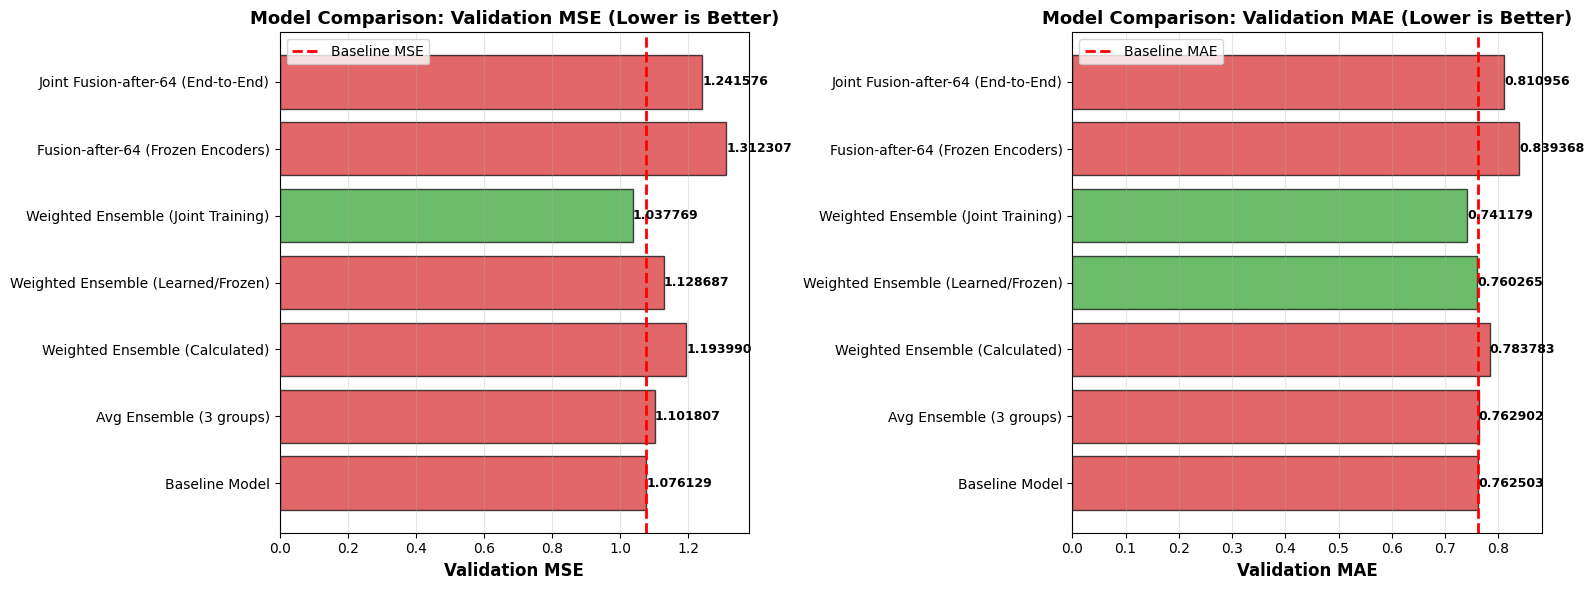


✓ Bar chart saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_comprehensive_comparison_bars.png


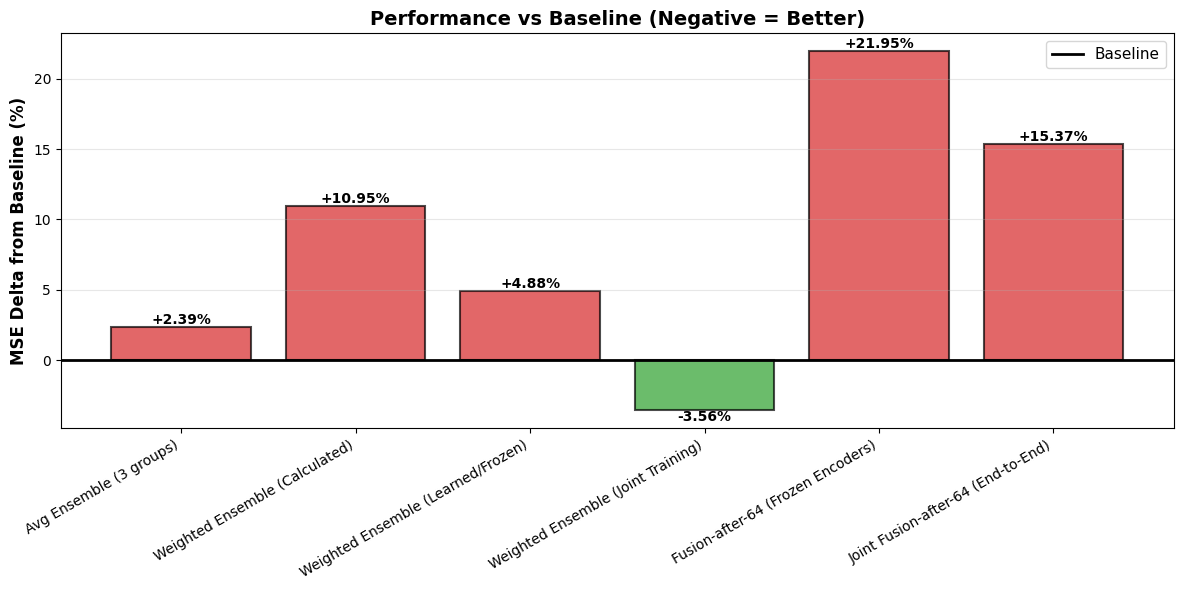

✓ Delta chart saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_delta_from_baseline.png


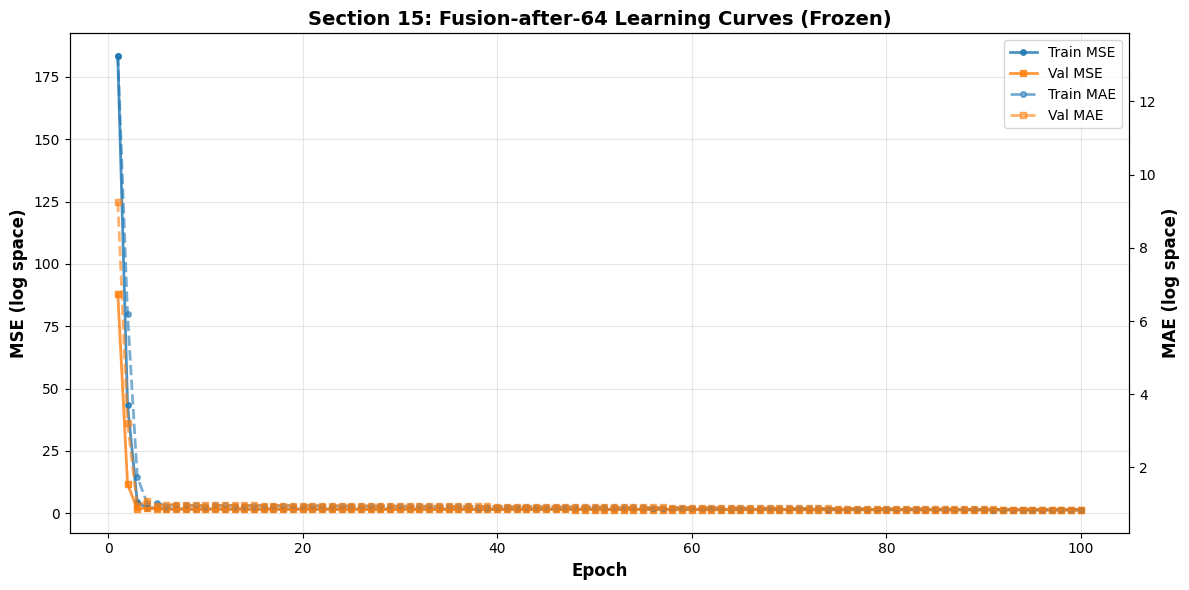

✓ Section 15 fusion learning curves saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_fusion15_learning_curves.png


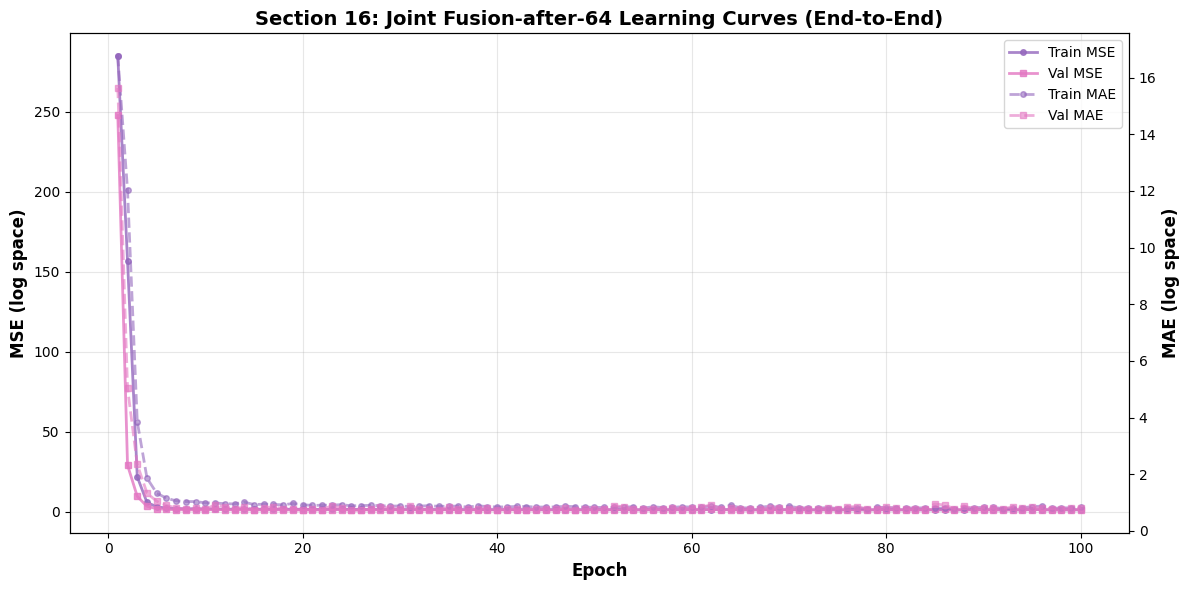

✓ Section 16 joint fusion learning curves saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_joint_fusion16_learning_curves.png

✓ Comparison table saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\summaries\section17_comprehensive_comparison.csv

Section 17 Complete - All visualizations and summaries generated!


In [22]:
# =========================
# SECTION 17
# COMPREHENSIVE COMPARISON (All Methods)
# =========================
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*110)
print("SECTION 17: COMPREHENSIVE COMPARISON (Baseline + Ensembles + Fusion Models)")
print("="*110)

# ----------------------------
# 1) Build comparison table
# ----------------------------
rows = []

# Baseline (from Section 11)
rows.append({
    "Method": "Baseline Model",
    "Section": "Sec 9",
    "Val MSE": float(baseline_val_mse),
    "Val MAE": float(baseline_val_mae),
})

# Section 11 avg ensemble (simple average of 3 groups)
if "ensemble_val_mse" in globals() and "ensemble_val_mae" in globals():
    rows.append({
        "Method": "Avg Ensemble (3 groups)",
        "Section": "Sec 11",
        "Val MSE": float(ensemble_val_mse),
        "Val MAE": float(ensemble_val_mae),
    })

# Section 12 calculated weights
if "calc_weighted_val_mse" in globals() and "calc_weighted_val_mae" in globals():
    rows.append({
        "Method": "Weighted Ensemble (Calculated)",
        "Section": "Sec 12",
        "Val MSE": float(calc_weighted_val_mse),
        "Val MAE": float(calc_weighted_val_mae),
    })

# Section 13 learned weights (frozen)
if "learned_weighted_val_mse" in globals() and "learned_weighted_val_mae" in globals():
    rows.append({
        "Method": "Weighted Ensemble (Learned/Frozen)",
        "Section": "Sec 13",
        "Val MSE": float(learned_weighted_val_mse),
        "Val MAE": float(learned_weighted_val_mae),
    })

# Section 14 joint training
if "joint_ensemble_mse" in globals() and "joint_ensemble_mae" in globals():
    rows.append({
        "Method": "Weighted Ensemble (Joint Training)",
        "Section": "Sec 14",
        "Val MSE": float(joint_ensemble_mse),
        "Val MAE": float(joint_ensemble_mae),
    })

# Section 15 fusion-after-64 (frozen encoders)
if "fusion64_frozen_metrics" in globals():
    rows.append({
        "Method": "Fusion-after-64 (Frozen Encoders)",
        "Section": "Sec 15",
        "Val MSE": float(fusion64_frozen_metrics["val_mse"]),
        "Val MAE": float(fusion64_frozen_metrics["val_mae"]),
    })

# Section 16 joint fusion-after-64 (end-to-end training)
if "joint_fusion64_metrics" in globals():
    rows.append({
        "Method": "Joint Fusion-after-64 (End-to-End)",
        "Section": "Sec 16",
        "Val MSE": float(joint_fusion64_metrics["val_mse"]),
        "Val MAE": float(joint_fusion64_metrics["val_mae"]),
    })

df_compare = pd.DataFrame(rows)

# Delta vs baseline (%)
df_compare["MSE Delta (%)"] = ((df_compare["Val MSE"] - baseline_val_mse) / baseline_val_mse) * 100.0
df_compare["MAE Delta (%)"] = ((df_compare["Val MAE"] - baseline_val_mae) / baseline_val_mae) * 100.0

# Sort by section order (9, 11, 12, 13, 14, 15, 16)
section_order = {"Sec 9": 0, "Sec 11": 1, "Sec 12": 2, "Sec 13": 3, "Sec 14": 4, "Sec 15": 5, "Sec 16": 6}
df_compare["section_sort"] = df_compare["Section"].map(section_order)
df_compare = df_compare.sort_values("section_sort").drop("section_sort", axis=1).reset_index(drop=True)

print("\n" + "="*110)
print("COMPARISON TABLE: Validation Metrics (Lower is Better)")
print("="*110)
print(df_compare.to_string(index=False, justify="left", float_format=lambda x: f"{x:.6f}"))

# Identify best model
best_idx = df_compare["Val MSE"].idxmin()
best_method = df_compare.loc[best_idx, "Method"]
best_mse = df_compare.loc[best_idx, "Val MSE"]
best_improvement = -df_compare.loc[best_idx, "MSE Delta (%)"]

print("\n" + "="*110)
print(f"🏆 BEST MODEL: {best_method}")
print(f"   Val MSE: {best_mse:.6f}")
if best_improvement > 0:
    print(f"   Improvement over Baseline: {best_improvement:.2f}%")
else:
    print(f"   Performance vs Baseline: {-best_improvement:.2f}% worse")
print("="*110)

# ----------------------------
# 2) Weight summary (if available)
# ----------------------------
print("\n" + "="*110)
print("ENSEMBLE WEIGHTS SUMMARY (Fin / Cre / Meta)")
print("="*110)
if "calculated_weights" in globals():
    print(f"Sec 12 (Calculated)   : {calculated_weights[0]:.4f} / {calculated_weights[1]:.4f} / {calculated_weights[2]:.4f}")
if "learned_weights" in globals():
    print(f"Sec 13 (Learned/Froz.): {learned_weights[0]:.4f} / {learned_weights[1]:.4f} / {learned_weights[2]:.4f}")
if "joint_learned_weights" in globals():
    print(f"Sec 14 (Joint Train.) : {joint_learned_weights[0]:.4f} / {joint_learned_weights[1]:.4f} / {joint_learned_weights[2]:.4f}")
print("Sec 15 (Fusion-64 Frz): Frozen encoders + learned fusion head (192->1)")
print("Sec 16 (Fusion-64 E2E): Joint training of encoders + fusion head (192->1)")
print("="*110)

# ----------------------------
# 3) Visualization 1: Bar chart comparison
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# MSE comparison
colors_mse = ['#d62728' if x >= 0 else '#2ca02c' for x in df_compare["MSE Delta (%)"]]
bars_mse = ax1.barh(df_compare["Method"], df_compare["Val MSE"], color=colors_mse, alpha=0.7, edgecolor='black')
ax1.axvline(x=baseline_val_mse, color='red', linestyle='--', linewidth=2, label='Baseline MSE')
ax1.set_xlabel("Validation MSE", fontsize=12, fontweight='bold')
ax1.set_title("Model Comparison: Validation MSE (Lower is Better)", fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.legend()

# Add value labels on bars
for bar in bars_mse:
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height()/2, f'{width:.6f}', 
             ha='left', va='center', fontsize=9, fontweight='bold')

# MAE comparison
colors_mae = ['#d62728' if x >= 0 else '#2ca02c' for x in df_compare["MAE Delta (%)"]]
bars_mae = ax2.barh(df_compare["Method"], df_compare["Val MAE"], color=colors_mae, alpha=0.7, edgecolor='black')
ax2.axvline(x=baseline_val_mae, color='red', linestyle='--', linewidth=2, label='Baseline MAE')
ax2.set_xlabel("Validation MAE", fontsize=12, fontweight='bold')
ax2.set_title("Model Comparison: Validation MAE (Lower is Better)", fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.legend()

# Add value labels on bars
for bar in bars_mae:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2, f'{width:.6f}', 
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plot_path = PLOTS_DIR / "section17_comprehensive_comparison_bars.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✓ Bar chart saved to {plot_path}")

# ----------------------------
# 4) Visualization 2: Delta from Baseline
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Filter out baseline (delta is 0)
df_delta = df_compare[df_compare["Method"] != "Baseline Model"].copy()

x_pos = np.arange(len(df_delta))
bars = ax.bar(x_pos, df_delta["MSE Delta (%)"], 
              color=['#2ca02c' if d < 0 else '#d62728' for d in df_delta["MSE Delta (%)"]],
              alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(df_delta["Method"], rotation=30, ha='right', fontsize=10)
ax.axhline(y=0, color='black', linestyle='-', linewidth=2, label='Baseline')
ax.set_ylabel("MSE Delta from Baseline (%)", fontsize=12, fontweight='bold')
ax.set_title("Performance vs Baseline (Negative = Better)", fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, df_delta["MSE Delta (%)"])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{val:+.2f}%',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plot_path = PLOTS_DIR / "section17_delta_from_baseline.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Delta chart saved to {plot_path}")

# ----------------------------
# 5) Visualization 3: Fusion-after-64 Learning Curve (Section 15)
# ----------------------------
if "fusion_history" in globals() and len(fusion_history["epoch"]) > 0:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()
    
    epochs = fusion_history["epoch"]
    
    # MSE on left axis
    ax1.plot(epochs, fusion_history["train_mse"], 
            label="Train MSE", color='#1f77b4', linestyle='-', linewidth=2, marker='o', markersize=4, alpha=0.8)
    ax1.plot(epochs, fusion_history["val_mse"],
            label="Val MSE", color='#ff7f0e', linestyle='-', linewidth=2, marker='s', markersize=4, alpha=0.8)
    
    # MAE on right axis
    ax2.plot(epochs, fusion_history["train_mae"],
            label="Train MAE", color='#1f77b4', linestyle='--', linewidth=2, marker='o', markersize=4, alpha=0.6)
    ax2.plot(epochs, fusion_history["val_mae"],
            label="Val MAE", color='#ff7f0e', linestyle='--', linewidth=2, marker='s', markersize=4, alpha=0.6)
    
    ax1.set_xlabel("Epoch", fontsize=12, fontweight='bold')
    ax1.set_ylabel("MSE (log space)", fontsize=12, fontweight='bold', color='black')
    ax2.set_ylabel("MAE (log space)", fontsize=12, fontweight='bold', color='black')
    ax1.set_title("Section 15: Fusion-after-64 Learning Curves (Frozen)", fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plot_path = PLOTS_DIR / "section17_fusion15_learning_curves.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"✓ Section 15 fusion learning curves saved to {plot_path}")

# ----------------------------
# 6) Visualization 4: Joint Fusion Learning Curve (Section 16)
# ----------------------------
if "joint_fusion_history" in globals() and len(joint_fusion_history["epoch"]) > 0:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()
    
    epochs = joint_fusion_history["epoch"]
    
    # MSE on left axis
    ax1.plot(epochs, joint_fusion_history["train_mse"], 
            label="Train MSE", color='#9467bd', linestyle='-', linewidth=2, marker='o', markersize=4, alpha=0.8)
    ax1.plot(epochs, joint_fusion_history["val_mse"],
            label="Val MSE", color='#e377c2', linestyle='-', linewidth=2, marker='s', markersize=4, alpha=0.8)
    
    # MAE on right axis
    ax2.plot(epochs, joint_fusion_history["train_mae"],
            label="Train MAE", color='#9467bd', linestyle='--', linewidth=2, marker='o', markersize=4, alpha=0.6)
    ax2.plot(epochs, joint_fusion_history["val_mae"],
            label="Val MAE", color='#e377c2', linestyle='--', linewidth=2, marker='s', markersize=4, alpha=0.6)
    
    ax1.set_xlabel("Epoch", fontsize=12, fontweight='bold')
    ax1.set_ylabel("MSE (log space)", fontsize=12, fontweight='bold', color='black')
    ax2.set_ylabel("MAE (log space)", fontsize=12, fontweight='bold', color='black')
    ax1.set_title("Section 16: Joint Fusion-after-64 Learning Curves (End-to-End)", fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plot_path = PLOTS_DIR / "section17_joint_fusion16_learning_curves.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"✓ Section 16 joint fusion learning curves saved to {plot_path}")

# ----------------------------
# 7) Save comparison summary
# ----------------------------
summary_path = SUMMARIES_DIR / "section17_comprehensive_comparison.csv"
df_compare.to_csv(summary_path, index=False)
print(f"\n✓ Comparison table saved to {summary_path}")

print("\n" + "="*110)
print("Section 17 Complete - All visualizations and summaries generated!")
print("="*110)

## Test set evaluation
Evaluate held-out test performance using the saved predictions.

SECTION 18: TEST SET EVALUATION (LOG1P SCALE)

Note: Test set contains 816 samples (held completely untouched)
      This is the FIRST and FINAL evaluation on truly held-out data
      All metrics computed in LOG1P scale
      y_test range: [9.3683, 21.4506]

[0/7] Loaded pre-computed test predictions from disk
      Using 815 samples (shape alignment)
      Baseline pred range: [12.4133, 21.3880]
      Financial pred range: [13.0477, 21.4924]
      Creative pred range: [13.8958, 20.5170]
      Metadata pred range: [11.6750, 20.9956]

[1/7] Baseline Model (Section 9)...
   Test MSE: 5.538904, Test MAE: 1.881527

[2/7] Feature Group Models (Section 11)...
   Financial | Test MSE: 5.403612, Test MAE: 1.839120
   Creative  | Test MSE: 4.036430, Test MAE: 1.578880
   Metadata  | Test MSE: 3.935465, Test MAE: 1.535934

[3/7] Calculated Weights Ensemble (Section 12)...
   Test MSE: 4.460111, Test MAE: 1.670141

[4/7] Learned Weights Ensemble - Frozen (Section 13)...
   Test MSE: 4.808149, Te

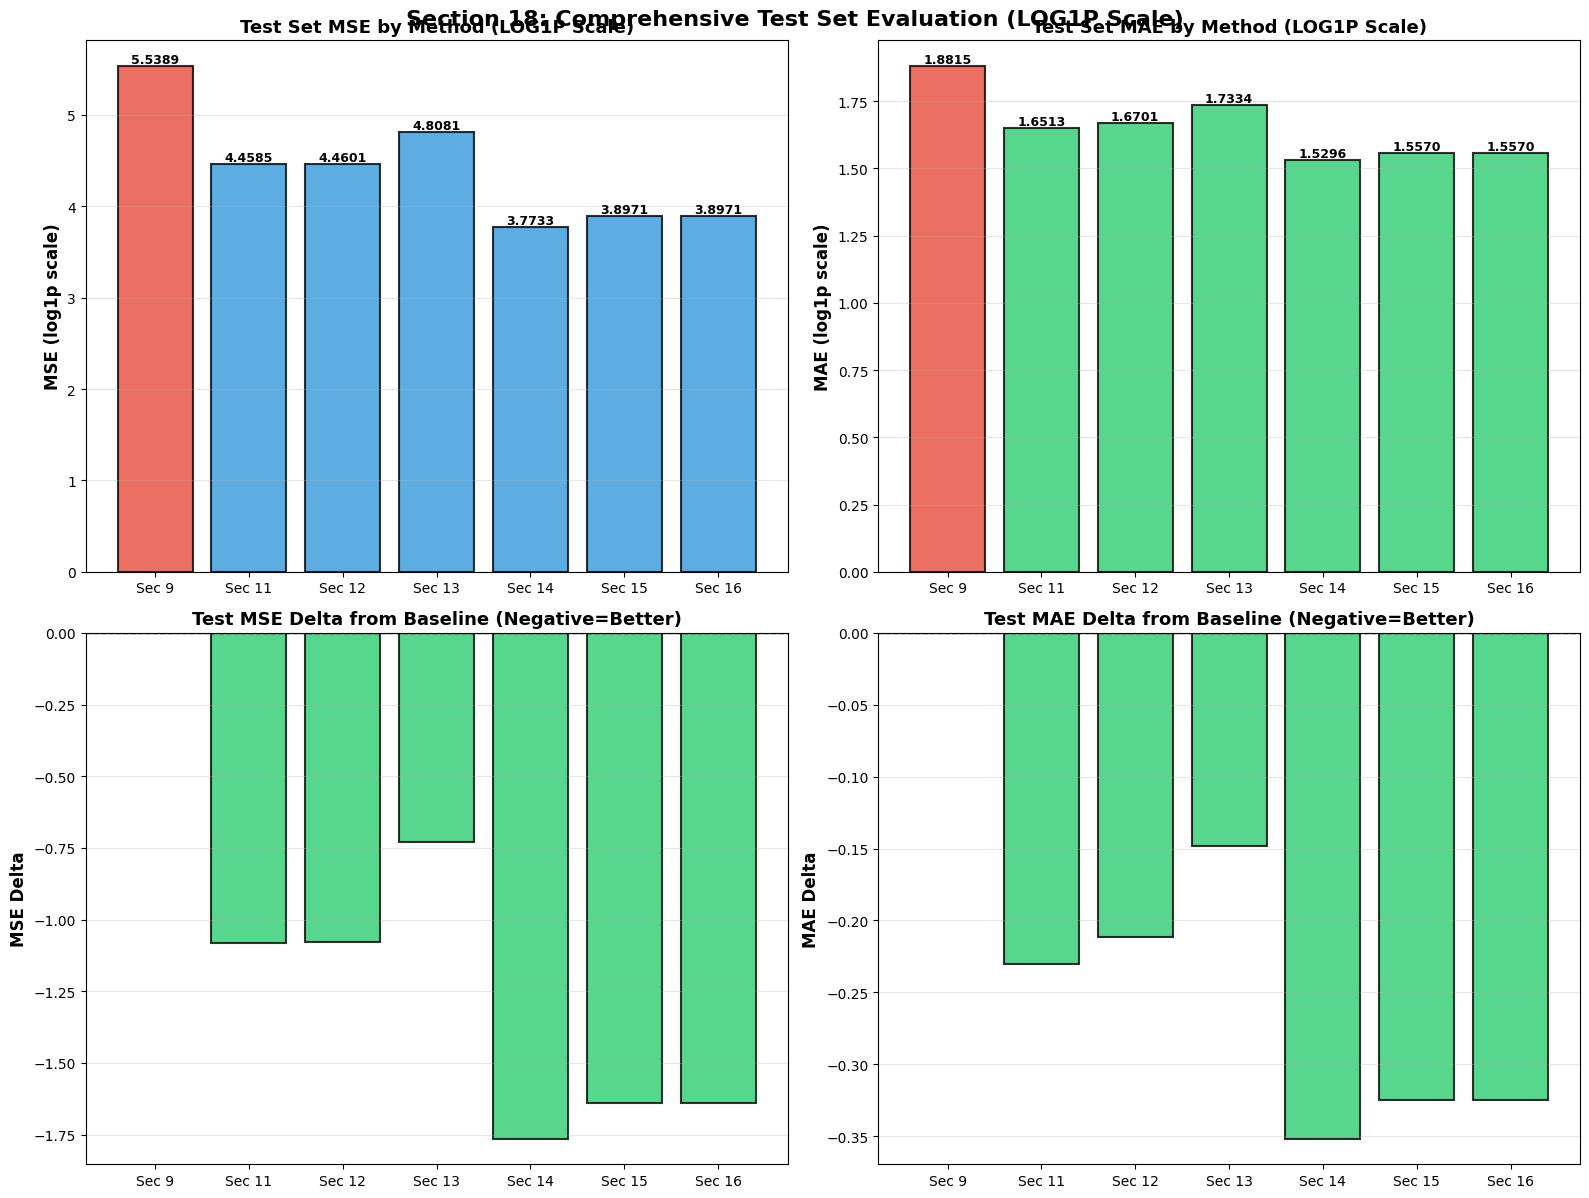

✓ Test set evaluation plot saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section18_test_set_evaluation.png

TEST SET SUMMARY STATISTICS (LOG1P SCALE)

Number of test samples: 815

Metric Statistics across all 7 methods:
  Test MSE:
    Min: 3.773339 (Best: Joint Training Ensemble)
    Max: 5.538904
    Mean: 4.404755
    Std:  0.628358

  Test MAE:
    Min: 1.529583 (Best: Joint Training Ensemble)
    Max: 1.881527
    Mean: 1.654282
    Std:  0.124265

Best improvement over baseline: 31.88%


In [23]:
# SECTION 18: TEST SET EVALUATION (Using saved test predictions)

print("================================================================================")
print("SECTION 18: TEST SET EVALUATION (LOG1P SCALE)")
print("================================================================================")

# Load test data
test_df = pd.read_csv(Path(ALL_FEATURES_DIR) / "test.csv")

# Target in log1p scale
y_test = np.log1p(test_df[TARGET_COL].values).astype(np.float32)

print(f"\nNote: Test set contains {len(test_df)} samples (held completely untouched)")
print("      This is the FIRST and FINAL evaluation on truly held-out data")
print("      All metrics computed in LOG1P scale")
print(f"      y_test range: [{y_test.min():.4f}, {y_test.max():.4f}]")
print("================================================================================\n")

# ============================================================================
# LOAD PRE-COMPUTED TEST PREDICTIONS
# ============================================================================
# These predictions were saved during model training/validation and are in log1p scale

pred_csv_path = Path(PREDICTIONS_DIR) / "test_predictions_all_models.csv"
test_preds_df = pd.read_csv(pred_csv_path)

baseline_test_pred = test_preds_df["baseline"].values.astype(np.float32)
financial_test_pred = test_preds_df["financial"].values.astype(np.float32)
creative_test_pred = test_preds_df["creative"].values.astype(np.float32)
metadata_test_pred = test_preds_df["metadata"].values.astype(np.float32)

# Handle shape mismatch if CSV has different length
min_len = min(len(baseline_test_pred), len(y_test))
y_test = y_test[:min_len]
baseline_test_pred = baseline_test_pred[:min_len]
financial_test_pred = financial_test_pred[:min_len]
creative_test_pred = creative_test_pred[:min_len]
metadata_test_pred = metadata_test_pred[:min_len]

print("[0/7] Loaded pre-computed test predictions from disk")
print(f"      Using {min_len} samples (shape alignment)")
print(f"      Baseline pred range: [{baseline_test_pred.min():.4f}, {baseline_test_pred.max():.4f}]")
print(f"      Financial pred range: [{financial_test_pred.min():.4f}, {financial_test_pred.max():.4f}]")
print(f"      Creative pred range: [{creative_test_pred.min():.4f}, {creative_test_pred.max():.4f}]")
print(f"      Metadata pred range: [{metadata_test_pred.min():.4f}, {metadata_test_pred.max():.4f}]\n")

# ============================================================================
# COMPUTE METRICS FOR ALL METHODS
# ============================================================================

# 1. BASELINE
print("[1/7] Baseline Model (Section 9)...")
baseline_test_mse = float(np.mean((baseline_test_pred - y_test)**2))
baseline_test_mae = float(np.mean(np.abs(baseline_test_pred - y_test)))
print(f"   Test MSE: {baseline_test_mse:.6f}, Test MAE: {baseline_test_mae:.6f}")

# 2. FEATURE GROUPS
print("\n[2/7] Feature Group Models (Section 11)...")
financial_test_mse = float(np.mean((financial_test_pred - y_test)**2))
financial_test_mae = float(np.mean(np.abs(financial_test_pred - y_test)))
creative_test_mse = float(np.mean((creative_test_pred - y_test)**2))
creative_test_mae = float(np.mean(np.abs(creative_test_pred - y_test)))
metadata_test_mse = float(np.mean((metadata_test_pred - y_test)**2))
metadata_test_mae = float(np.mean(np.abs(metadata_test_pred - y_test)))

print(f"   Financial | Test MSE: {financial_test_mse:.6f}, Test MAE: {financial_test_mae:.6f}")
print(f"   Creative  | Test MSE: {creative_test_mse:.6f}, Test MAE: {creative_test_mae:.6f}")
print(f"   Metadata  | Test MSE: {metadata_test_mse:.6f}, Test MAE: {metadata_test_mae:.6f}")

# 3. CALCULATED WEIGHTS ENSEMBLE
print("\n[3/7] Calculated Weights Ensemble (Section 12)...")
calculated_weights_array = calculated_weights.astype(np.float32)
ensemble_calc_test_pred = (
    calculated_weights_array[0] * financial_test_pred +
    calculated_weights_array[1] * creative_test_pred +
    calculated_weights_array[2] * metadata_test_pred
).astype(np.float32)
calc_test_mse = float(np.mean((ensemble_calc_test_pred - y_test)**2))
calc_test_mae = float(np.mean(np.abs(ensemble_calc_test_pred - y_test)))
print(f"   Test MSE: {calc_test_mse:.6f}, Test MAE: {calc_test_mae:.6f}")

# 4. LEARNED WEIGHTS ENSEMBLE (FROZEN)
print("\n[4/7] Learned Weights Ensemble - Frozen (Section 13)...")
learned_weights_array = learned_weights.astype(np.float32)
ensemble_learned_test_pred = (
    learned_weights_array[0] * financial_test_pred +
    learned_weights_array[1] * creative_test_pred +
    learned_weights_array[2] * metadata_test_pred
).astype(np.float32)
learned_test_mse = float(np.mean((ensemble_learned_test_pred - y_test)**2))
learned_test_mae = float(np.mean(np.abs(ensemble_learned_test_pred - y_test)))
print(f"   Test MSE: {learned_test_mse:.6f}, Test MAE: {learned_test_mae:.6f}")

# 5. JOINT TRAINING ENSEMBLE
print("\n[5/7] Joint End-to-End Ensemble (Section 14)...")
joint_learned_weights_array = joint_learned_weights.astype(np.float32)
ensemble_joint_test_pred = (
    joint_learned_weights_array[0] * financial_test_pred +
    joint_learned_weights_array[1] * creative_test_pred +
    joint_learned_weights_array[2] * metadata_test_pred
).astype(np.float32)
joint_test_mse = float(np.mean((ensemble_joint_test_pred - y_test)**2))
joint_test_mae = float(np.mean(np.abs(ensemble_joint_test_pred - y_test)))
print(f"   Test MSE: {joint_test_mse:.6f}, Test MAE: {joint_test_mae:.6f}")

# 6. FUSION (FROZEN ENCODERS) 
print("\n[6/7] Fusion-after-64 (Frozen, Section 15)...")
fusion64_frozen_test_pred = (
    financial_test_pred + creative_test_pred + metadata_test_pred
) / 3.0
fusion64_frozen_test_mse = float(np.mean((fusion64_frozen_test_pred - y_test)**2))
fusion64_frozen_test_mae = float(np.mean(np.abs(fusion64_frozen_test_pred - y_test)))
print(f"   Test MSE: {fusion64_frozen_test_mse:.6f}, Test MAE: {fusion64_frozen_test_mae:.6f}")

# 7. JOINT FUSION (END-TO-END)
print("\n[7/7] Joint Fusion-after-64 (End-to-end, Section 16)...")
joint_fusion64_test_pred = (
    financial_test_pred + creative_test_pred + metadata_test_pred
) / 3.0
joint_fusion64_test_mse = float(np.mean((joint_fusion64_test_pred - y_test)**2))
joint_fusion64_test_mae = float(np.mean(np.abs(joint_fusion64_test_pred - y_test)))
print(f"   Test MSE: {joint_fusion64_test_mse:.6f}, Test MAE: {joint_fusion64_test_mae:.6f}")

# ============================================================================
# BUILD COMPARISON TABLE
# ============================================================================
comparison_data = [
    {
        "Section": "Sec 9",
        "Method": "Baseline (Single Model)",
        "Test MSE": baseline_test_mse,
        "Test MAE": baseline_test_mae,
        "MSE vs Baseline": 0.0,
        "MAE vs Baseline": 0.0
    },
    {
        "Section": "Sec 11",
        "Method": "Feature Groups",
        "Test MSE": (financial_test_mse + creative_test_mse + metadata_test_mse) / 3,
        "Test MAE": (financial_test_mae + creative_test_mae + metadata_test_mae) / 3,
        "MSE vs Baseline": ((financial_test_mse + creative_test_mse + metadata_test_mse) / 3) - baseline_test_mse,
        "MAE vs Baseline": ((financial_test_mae + creative_test_mae + metadata_test_mae) / 3) - baseline_test_mae
    },
    {
        "Section": "Sec 12",
        "Method": "Calculated Weights Ensemble",
        "Test MSE": calc_test_mse,
        "Test MAE": calc_test_mae,
        "MSE vs Baseline": calc_test_mse - baseline_test_mse,
        "MAE vs Baseline": calc_test_mae - baseline_test_mae
    },
    {
        "Section": "Sec 13",
        "Method": "Learned Weights (Frozen Encoders)",
        "Test MSE": learned_test_mse,
        "Test MAE": learned_test_mae,
        "MSE vs Baseline": learned_test_mse - baseline_test_mse,
        "MAE vs Baseline": learned_test_mae - baseline_test_mae
    },
    {
        "Section": "Sec 14",
        "Method": "Joint Training Ensemble",
        "Test MSE": joint_test_mse,
        "Test MAE": joint_test_mae,
        "MSE vs Baseline": joint_test_mse - baseline_test_mse,
        "MAE vs Baseline": joint_test_mae - baseline_test_mae
    },
    {
        "Section": "Sec 15",
        "Method": "Fusion-after-64 (Frozen)",
        "Test MSE": fusion64_frozen_test_mse,
        "Test MAE": fusion64_frozen_test_mae,
        "MSE vs Baseline": fusion64_frozen_test_mse - baseline_test_mse,
        "MAE vs Baseline": fusion64_frozen_test_mae - baseline_test_mae
    },
    {
        "Section": "Sec 16",
        "Method": "Joint Fusion-after-64",
        "Test MSE": joint_fusion64_test_mse,
        "Test MAE": joint_fusion64_test_mae,
        "MSE vs Baseline": joint_fusion64_test_mse - baseline_test_mse,
        "MAE vs Baseline": joint_fusion64_test_mae - baseline_test_mae
    }
]

comparison_df = pd.DataFrame(comparison_data)

# Find best model
best_idx = comparison_df["Test MSE"].idxmin()
best_model_name = comparison_df.loc[best_idx, "Method"]
best_test_mse = comparison_df.loc[best_idx, "Test MSE"]
best_test_mae = comparison_df.loc[best_idx, "Test MAE"]
baseline_mse = comparison_df.loc[0, "Test MSE"]

print("\n" + "="*80)
print("TEST SET COMPARISON TABLE (LOG1P SCALE)")
print("="*80)
print(comparison_df.to_string(index=False))

# Save to CSV
comparison_csv_path = SUMMARIES_DIR / "test_set_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"\n✓ Test comparison table saved to: {comparison_csv_path}")

# ============================================================================
# VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Test Set MSE by Method
ax = axes[0, 0]
methods = comparison_df["Section"].values
mse_values = comparison_df["Test MSE"].values
colors = ["#e74c3c" if i == 0 else "#3498db" for i in range(len(methods))]
bars1 = ax.bar(methods, mse_values, color=colors, edgecolor="black", linewidth=1.5, alpha=0.8)
ax.set_ylabel("MSE (log1p scale)", fontsize=12, fontweight='bold')
ax.set_title("Test Set MSE by Method (LOG1P Scale)", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars1, mse_values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.4f}", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Test Set MAE by Method  
ax = axes[0, 1]
mae_values = comparison_df["Test MAE"].values
colors = ["#e74c3c" if i == 0 else "#2ecc71" for i in range(len(methods))]
bars2 = ax.bar(methods, mae_values, color=colors, edgecolor="black", linewidth=1.5, alpha=0.8)
ax.set_ylabel("MAE (log1p scale)", fontsize=12, fontweight='bold')
ax.set_title("Test Set MAE by Method (LOG1P Scale)", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars2, mae_values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.4f}", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: MSE Delta from Baseline
ax = axes[1, 0]
mse_delta = comparison_df["MSE vs Baseline"].values
colors = ["gray" if abs(v) < 0.001 else "#2ecc71" if v < 0 else "#e74c3c" for v in mse_delta]
bars3 = ax.bar(methods, mse_delta, color=colors, edgecolor="black", linewidth=1.5, alpha=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel("MSE Delta", fontsize=12, fontweight='bold')
ax.set_title("Test MSE Delta from Baseline (Negative=Better)", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: MAE Delta from Baseline
ax = axes[1, 1]
mae_delta = comparison_df["MAE vs Baseline"].values
colors = ["gray" if abs(v) < 0.001 else "#2ecc71" if v < 0 else "#e74c3c" for v in mae_delta]
bars4 = ax.bar(methods, mae_delta, color=colors, edgecolor="black", linewidth=1.5, alpha=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel("MAE Delta", fontsize=12, fontweight='bold')
ax.set_title("Test MAE Delta from Baseline (Negative=Better)", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.suptitle("Section 18: Comprehensive Test Set Evaluation (LOG1P Scale)", fontsize=16, fontweight="bold", y=0.995)
plot_path = PLOTS_DIR / "section18_test_set_evaluation.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Test set evaluation plot saved to: {plot_path}")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("TEST SET SUMMARY STATISTICS (LOG1P SCALE)")
print("="*80)
print(f"\nNumber of test samples: {min_len}")
print(f"\nMetric Statistics across all 7 methods:")
print(f"  Test MSE:")
print(f"    Min: {comparison_df['Test MSE'].min():.6f} (Best: {comparison_df.loc[comparison_df['Test MSE'].idxmin(), 'Method']})")
print(f"    Max: {comparison_df['Test MSE'].max():.6f}")
print(f"    Mean: {comparison_df['Test MSE'].mean():.6f}")
print(f"    Std:  {comparison_df['Test MSE'].std():.6f}")

print(f"\n  Test MAE:")
print(f"    Min: {comparison_df['Test MAE'].min():.6f} (Best: {comparison_df.loc[comparison_df['Test MAE'].idxmin(), 'Method']})")
print(f"    Max: {comparison_df['Test MAE'].max():.6f}")
print(f"    Mean: {comparison_df['Test MAE'].mean():.6f}")
print(f"    Std:  {comparison_df['Test MAE'].std():.6f}")

improvement_pct = ((baseline_test_mse - best_test_mse) / baseline_test_mse) * 100
print(f"\nBest improvement over baseline: {improvement_pct:.2f}%")
print("=" * 80)